# TP n°3 : Méta-modèles pour le traitement des incertitudes

### Importation des librairies

In [1]:
pip install openturns

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import time
from IPython.display import clear_output

import openturns as ot
from openturns.viewer import View
import sys


## Planification d’expériences numériques


### Plans Maximin

Pour cette première partie, nous allons construire un plan d’expériences maximin de 9 points et 2 variables 𝑈[0,1] (matrice de 9 lignes à 2 colonnes).

 L’idée est de générer un grand nombre de plans aléatoires et de prendre le meilleur au sens de la maximisation de la distance minimale entre 2 points du plan (critère dit maximin).

 La fonction codant cette distance se nomme SpaceFillingMinDIst. Visualiser ce plan par rapport à un plan aléatoire pur (Monte Carlo).



In [ ]:
def generate_random(nb_points, nb_variables):
  PE = np.random.random_sample((nb_points,nb_variables))

  return PE

def Monte_Carlo_Maximin(N,nb_points, nb_variables):

  k = 1
  best_plan = generate_random(nb_points, nb_variables)
  best_crit = ot.SpaceFillingMinDist().evaluate(best_plan)

  while k < N:
    new_plan = generate_random(nb_points,nb_variables)
    new_crit = ot.SpaceFillingMinDist().evaluate(new_plan)

    if new_crit > best_crit:
      best_plan = new_plan
      best_crit = new_crit

    k += 1

  return best_plan, best_crit


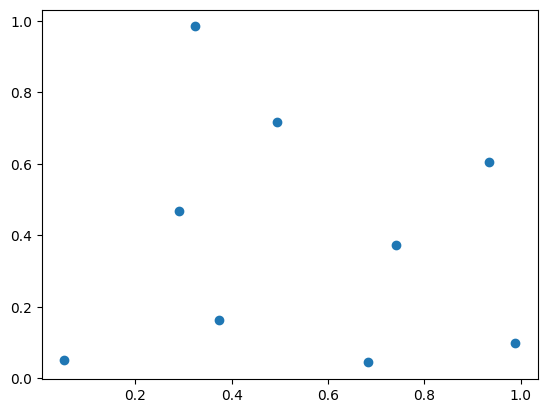

In [ ]:
nb_points = 9
nb_variables = 2

pXp, crit = Monte_Carlo_Maximin(100000,9, 2)
plt.scatter(pXp[:,0],pXp[:,1])

### Plans LHS

Nous considérons désormais les Hypercubes latins. Nous allons construire une fonction permettant de générer de tels plans, à marge uniforme (méthode de base sans tirage aléatoire dans chaque strate, uniquement le choix des strates par dimension).

Nous construirons ensuite un LHS de 20 points et 2 variables 𝑈[0,1].

In [ ]:
from pickle import PERSID
def generate_LHS(nb_points, nb_variables):

  PE = np.zeros((nb_points,nb_variables))
  for k in range(nb_variables):
    PE[:,k] = np.random.permutation(np.linspace(0, 1, nb_points))

  return PE

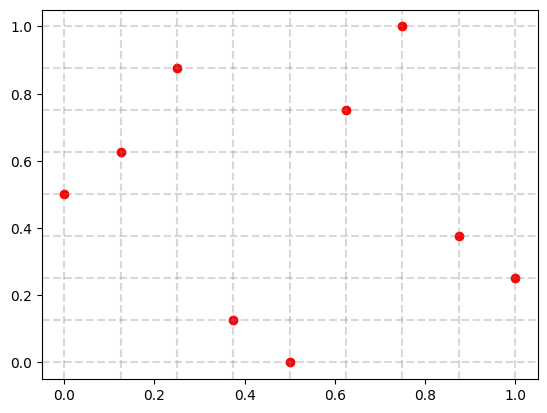

In [ ]:
nb_points = 9
nb_variables = 2

pe = generate_LHS(nb_points,nb_variables)

x = np.linspace(0,1,nb_points)
y = np.linspace(0,1,nb_points)

plt.scatter(pe[:,0],pe[:,1],color='red')

for k in range(nb_points):
  plt.axhline(y=y[k],color='grey',linestyle='--',alpha=0.3)
  plt.axvline(x=x[k],color='grey',linestyle='--',alpha=0.3)

### LHS Optimisé

On se propose ici de construire deux LHS optimisés avec le critère MinDist. Pour cela, nous allons implémenter 2 méthodes différentes :

- Approche par Monte-Carlo : générer un grand nombre de LHS et prendre le meilleur au sens maximin

- Utiliser la fonction SimulatedAnnealingLHS d’OpenTURNS.


In [ ]:
def General_Monte_Carlo_Maximin(N,nb_points, nb_variables,fun):

  k = 1
  best_plan = fun(nb_points, nb_variables)
  best_crit = ot.SpaceFillingMinDist().evaluate(best_plan)

  while k < N:
    new_plan = fun(nb_points,nb_variables)
    new_crit = ot.SpaceFillingMinDist().evaluate(new_plan)

    if new_crit > best_crit:
      best_plan = new_plan
      best_crit = new_crit

    k += 1

  return best_plan, best_crit


Avec le plan LHS       :  0.354
Avec le plan Aléatoire :  0.301



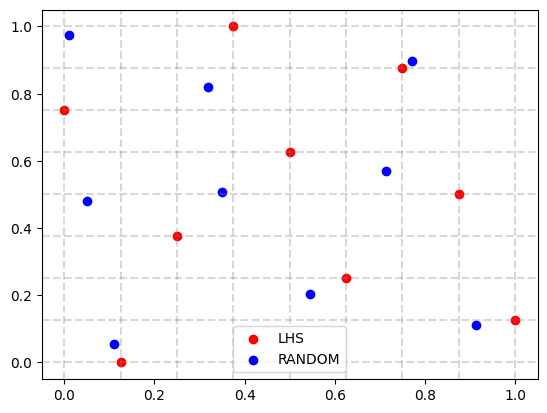

In [ ]:
plan_LHS, m_LHS = General_Monte_Carlo_Maximin(100000,9, 2,generate_LHS)
plan_M, m_M = General_Monte_Carlo_Maximin(100000,9, 2,generate_random)

print("Avec le plan LHS       : ", np.round(m_LHS,3))
print("Avec le plan Aléatoire : ", np.round(m_M,3))
print("")

x = np.linspace(0,1,nb_points)
y = np.linspace(0,1,nb_points)

plt.scatter(plan_LHS[:,0],plan_LHS[:,1],color='red',label="LHS")
plt.scatter(plan_M[:,0],plan_M[:,1],color='blue',label="RANDOM")

for k in range(nb_points):
  plt.axhline(y=y[k],color='grey',linestyle='--',alpha=0.3)
  plt.axvline(x=x[k],color='grey',linestyle='--',alpha=0.3)

plt.legend()

En comparant la distance minimale entre les points de chaque plan d'expérience obtenu, on observe que, pour un nombre de simulation donné, les plans LHS semblent être meilleur (le critère est supérieur).

Ceci est rassurant, puisque nous utilisons ici une stratégie de remplissage, là où, avec la première implémentation, les plans sont générés de manière complètement aléatoire.

En guise de 2e comparaison, nous allons utiliser la fonction ```LHSExperiment``` de Openturns, afin de comparer le plan d'expérience rendu avec ceux obtenus par simulation Monte-Carlo.

In [ ]:
# Nombre de variables et nombre de points
nb_variables = 2
nb_points = 9

# Construction d'un LHS Algorithm
distribution = ot.JointDistribution([ot.Uniform(0.0, 1.0)]*nb_variables)
lhs = ot.LHSExperiment(distribution, nb_points)
lhs.setAlwaysShuffle(True) # randomized

# Définition de la manière de remplir l'espace
spaceFilling = ot.SpaceFillingC2()
# Profil géométrique
geomProfile = ot.GeometricProfile(10.0, 0.95, 2000)

# Obtention du plan d'expérience optimisé LHS
optimalLHSAlgorithm = ot.SimulatedAnnealingLHS(lhs, spaceFilling, geomProfile)

Avec le plan LHS       :  0.3535533905932738
Avec le plan Aléatoire :  0.30083644256294234
Avec le plan OPTIMISE  :  0.2515649461057585



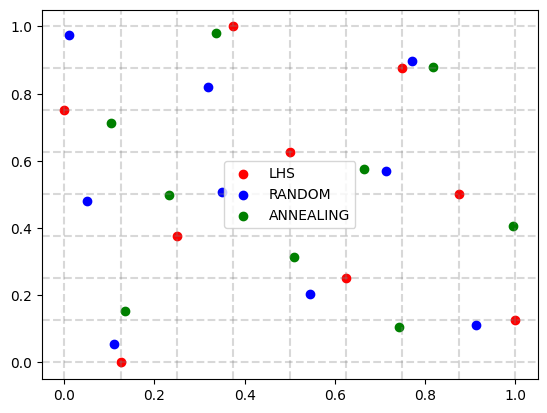

In [ ]:
# Affichage graphique des plans d'expérience
plan_O = optimalLHSAlgorithm.generate()
m_O = ot.SpaceFillingMinDist().evaluate(plan_O)

print("Avec le plan LHS       : ", m_LHS)
print("Avec le plan Aléatoire : ", m_M)
print("Avec le plan OPTIMISE  : ", m_O)
print("")

x = np.linspace(0,1,nb_points)
y = np.linspace(0,1,nb_points)

plt.scatter(plan_LHS[:,0],plan_LHS[:,1],color='red',label="LHS")
plt.scatter(plan_M[:,0],plan_M[:,1],color='blue',label="RANDOM")
plt.scatter(plan_O[:,0],plan_O[:,1],color='green',label="ANNEALING")

for k in range(nb_points):
  plt.axhline(y=y[k],color='grey',linestyle='--',alpha=0.3)
  plt.axvline(x=x[k],color='grey',linestyle='--',alpha=0.3)

plt.legend()

Assez étonnement, le plan d'expérience LHS obtenu par simulation de Monte-Carlo est meilleur que celui rendu par ```SimulatedAnnealingLHS```. Toutefois, le temps de recherche par simulation est bien plus long que celui rendu avec cette fonction. Il se peut donc que, dans un cas multidimensionnel, où plus de points sont recherchés, la méthode utilisant cette fonction soit meilleure.

### Suites à faible discrépance

Dans cette nouvelle partie, nous allons considérer 2 suites à faible discrépance. Dans notre contexte, la discrépance mesure l'écart maximal du plan d'expérience avec l'équirépartition. Cette quantité est donc un nouvel critère de comparaison des plans d'expérience.



#### Suite de Sobol

Nous considérons ici une suite de Sobol, que nous allons appliquer à notre cas d'étude (9 points et 2 variables 𝑈[0,1]).

Nous pourrons visualiser le plan, et le comparer aux autres plans précédents, via le critère maximin, et la valeur de discrépance.

Avec le plan Aléatoire :  0.301
Avec le plan Annealing :  0.252
Avec le plan LHS       :  0.354
Avec le plan Sobol     :  0.177



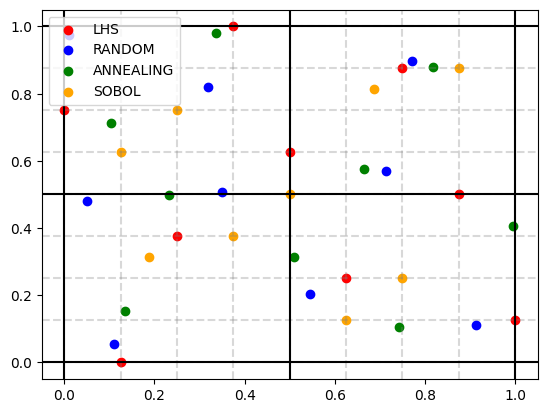

In [ ]:
nb_points = 9
nb_variables = 2

sobol_sequence = ot.SobolSequence(nb_variables)
plan_S = sobol_sequence.generate(nb_points)

m_S = ot.SpaceFillingMinDist().evaluate(plan_S)

print("Avec le plan Aléatoire : ", np.round(m_M,3))
print("Avec le plan Annealing : ", np.round(m_O,3))
print("Avec le plan LHS       : ", np.round(m_LHS,3))
print("Avec le plan Sobol     : ", np.round(m_S,3))
print("")

x = np.linspace(0,1,nb_points)
y = np.linspace(0,1,nb_points)

plt.scatter(plan_LHS[:,0],plan_LHS[:,1],color='red',label="LHS")
plt.scatter(plan_M[:,0],plan_M[:,1],color='blue',label="RANDOM")
plt.scatter(plan_O[:,0],plan_O[:,1],color='green',label="ANNEALING")
plt.scatter(plan_S[:,0],plan_S[:,1],color='orange',label="SOBOL")

for k in range(nb_points):
  plt.axhline(y=y[k],color='grey',linestyle='--',alpha=0.3)
  plt.axvline(x=x[k],color='grey',linestyle='--',alpha=0.3)

for j in range(3):
  plt.axhline(y=1/2*j,color='black')
  plt.axvline(x=1/2*j,color='black')

plt.legend()

In [ ]:
def discrepance_L2(points):
    return ot.LowDiscrepancySequence().computeStarDiscrepancy(points)

In [ ]:
print("             Maximin       Discrépance L2      ")
print("RANDOM    : ", np.round(m_M,3),"    |      ",np.round(discrepance_L2(plan_M),3))
print("ANNEALING : ", np.round(m_O,3),"    |      ",np.round(discrepance_L2(plan_O),3))
print("LHS       : ", np.round(m_LHS,3),"    |      ",np.round(discrepance_L2(plan_LHS),3))
print("SOBOL     : ", np.round(m_S,3),"    |      ",np.round(discrepance_L2(plan_S),3))
print("")

             Maximin       Discrépance L2      
RANDOM    :  0.301     |       0.155
ANNEALING :  0.252     |       0.115
LHS       :  0.354     |       0.128
SOBOL     :  0.177     |       0.234



Comme nous pouvons le voir, le critère de discrépance ne semble pas varier de la même manière que le critère maximin. Ainsi, le plan de Sobol est "le moins bon" au sens du maximin, mais est le meilleur au sens de la discrépance.

Ceci signifie que la suite de Sobol nous donne le plan le plus éloigné du plan uniforme (représenté par les lignes noires ci-dessus). Toutefois, certains points sont assez proches les uns des autres, ce qui conduit à une valeur de maximin assez faible.

#### Suite de Halton

Nous continuons notre étude des suites à faible discrépance, avec la suite de Halton. Nous allons l'évaluer avec 200 points et 8 variables sur 𝑈[0,1]. Nous visualiserons tous les scatterplots de ce plan avec la fonction.


In [ ]:
nb_points = 200
nb_variables = 8

halton_sequence = ot.HaltonSequence(nb_variables)
plans_H = halton_sequence.generate(nb_points)

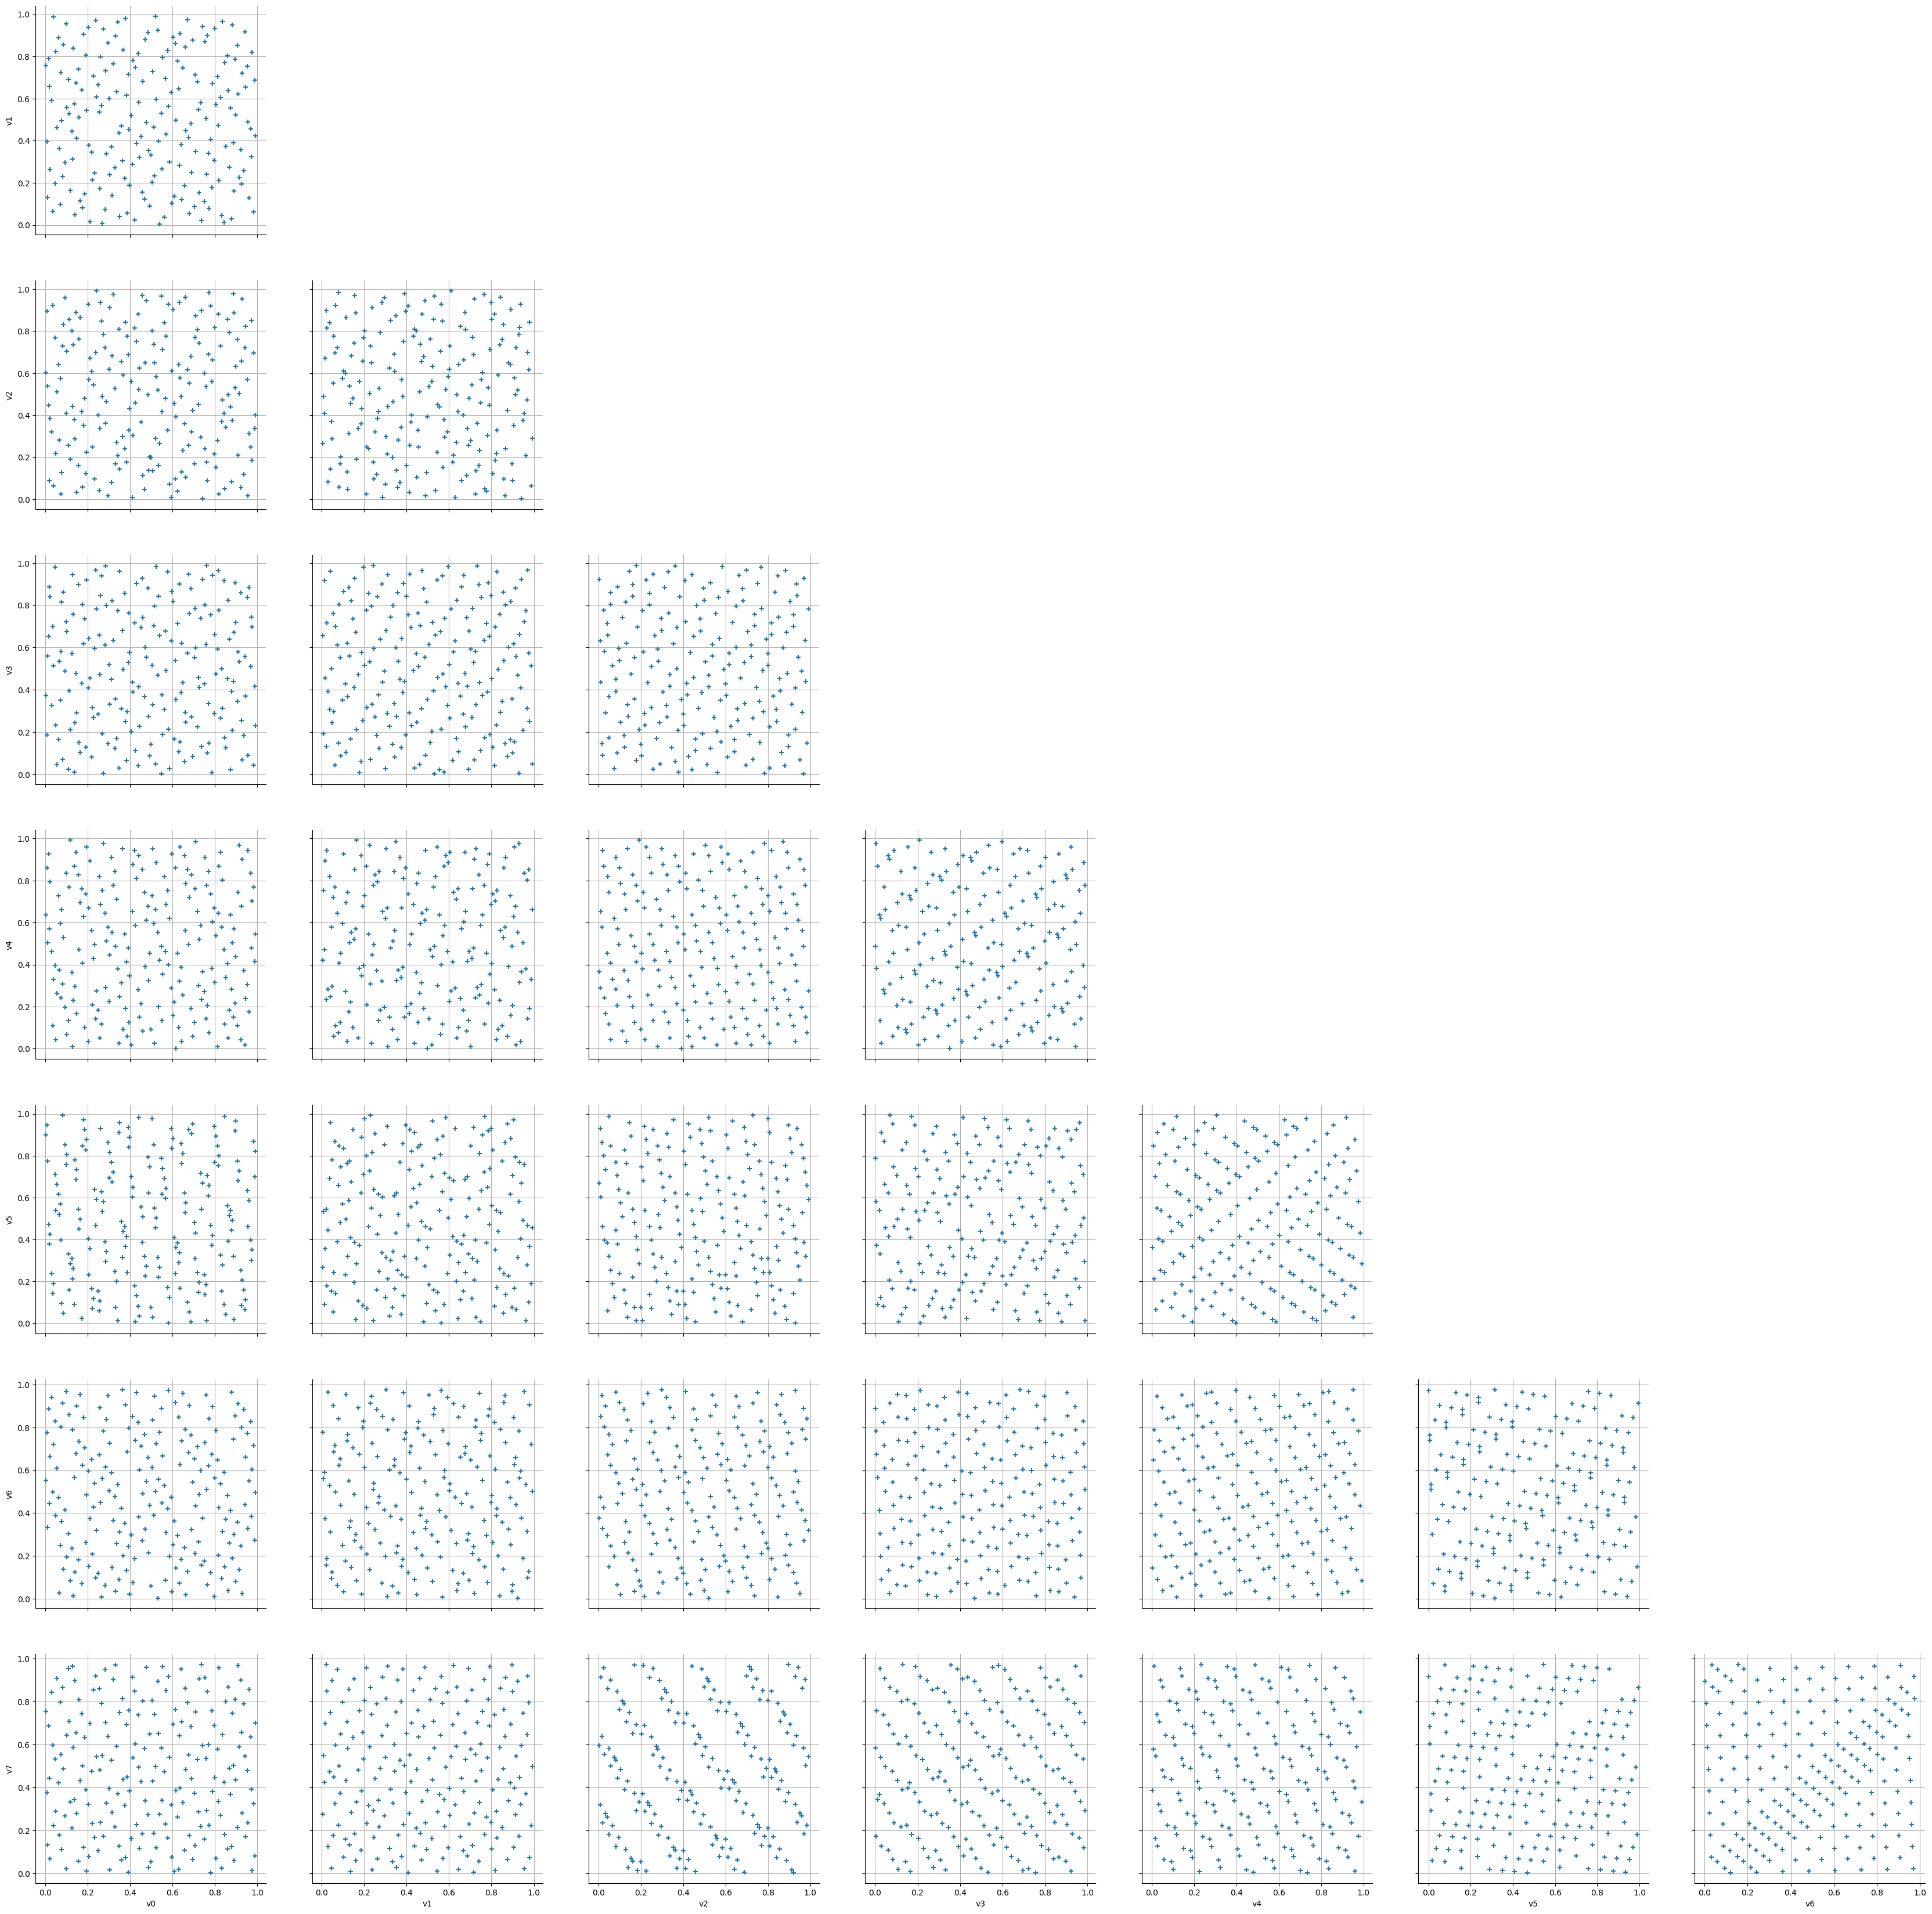

In [ ]:
clouds = ot.VisualTest.DrawPairs(plans_H)
View(clouds).show()

Nous pouvons ici remarquer que de nombreux motifs sont présents dans les scatterplots ci-dessus. Par exemple, sur la dernière ligne, nous observons des droites parallèles les unes aux autres sur 4 des 7 graphiques proposés.

Ces observations ne sont bien entendu pas souhaitables dans notre cas, puisque nous souhaiterons combler l'espace entier (ici, des droite sont complètement vides).

#### Comparaison des motifs avec la suite de Sobol

Nous pouvons donc réaliser le même travail avec la suite de Sobol, afin d'apprécier toute éventuelle différence et/ou point commun.

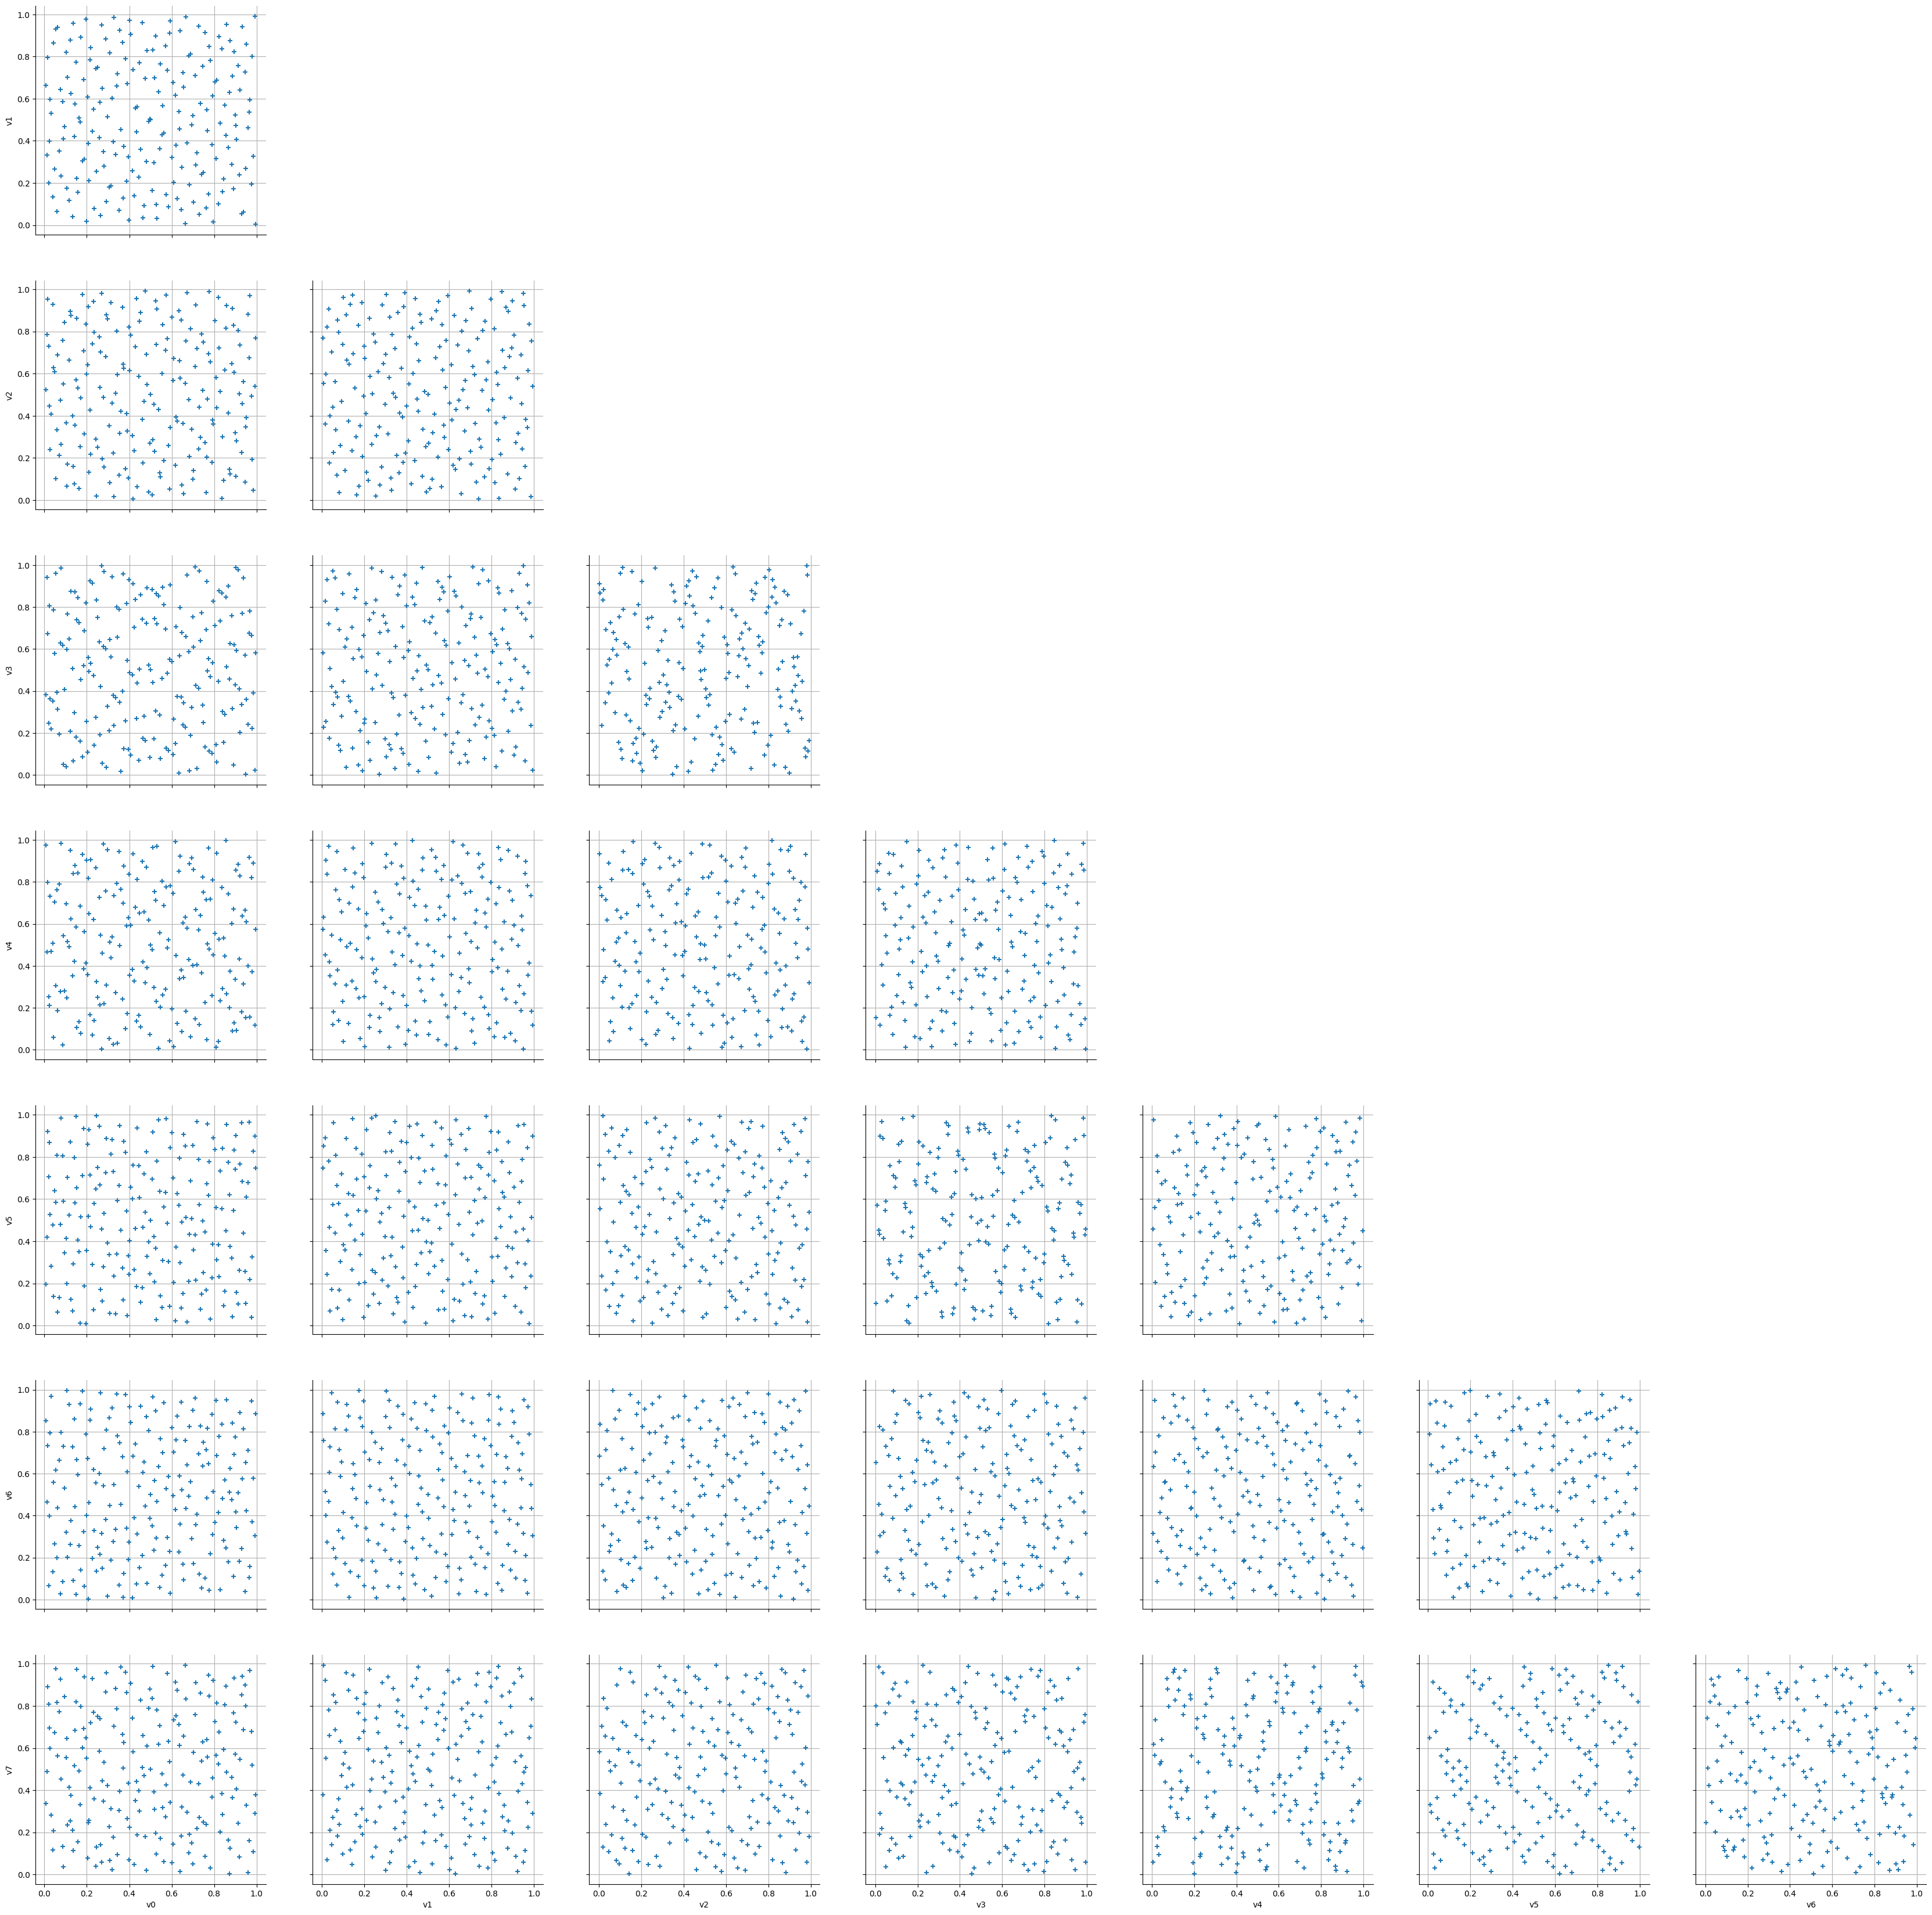

In [ ]:
nb_points = 200
nb_variables = 8

sobol_sequence = ot.SobolSequence(nb_variables)
plans_S = sobol_sequence.generate(nb_points)

clouds_S = ot.VisualTest.DrawPairs(plans_S)
View(clouds_S).show()

Avec les suites de Sobol, nous n'observons plus le type de motif précédent. En effet, ici, pour  tous les graphes affichés, les points semblent être séparés les uns des autres sans structure particulière.

Ceci illustre l'un des avantages à utiliser la suite de Sobol plutôt qu'une autre suite à faible discrépance, comme la suite de Halton.

## Prise en main des processus gaussiens avec OpenTURNS

Dans ce 2e exercice, nous allons mettre en pratique l'utilisation du package OpenTURNS pour l'ajustement d'un modèle de Krigeage sur des données.

A cet effet, nous allons réutiliser la fonction d'étude du TP n°2, et le plan d'expérience n°1 proposé ("pXp1").

### Données

In [ ]:
# Définition de la fonction d'étude
def f(x):
    y = np.exp(-(x*25+40)**2/350)*20-np.exp(-(x*25-10)**2/50)*5+np.sin((x*25+50)/80)*25-19
    return y

# Plan d'expérience donné
pXp1 = np.array([[-1.8],[-1.4],[-1.0],[-0.6],[-0.2],[0.2],[0.6],[1.0],[1.4],[1.8]])
# Evaluation de la fonction sur ce plan d'expérience
Z1 = f(pXp1)
# Domaine d'interpolation de la fonction
D = np.linspace(-2,2,400)

### Fonctions d'ajustement et d'affichage

In [ ]:
def fit_Kriging(pXp, Z, covariance, D):

  # Définition du modèle de Krigeage
  kriging_model = ot.KrigingAlgorithm(pXp, Z, covariance)
  # Ajustement du modèle sur le plan d'expérience
  kriging_model.run()

  # Récupération du meta_modèle
  krigingResult = kriging_model.getResult()
  krigingMetamodel = krigingResult.getMetaModel()
  # Récupération de la variance du modèle
  variance_model = np.sqrt([[krigingResult.getConditionalCovariance(xx)[0, 0]] for xx in D.reshape((400,1))])

  return krigingResult, krigingMetamodel, variance_model

In [ ]:
def plot_Kriging(ax, D, pXp, Z, D_test, y_fit, var, label):
  ax.plot(D, f(D), label="f(x)")
  ax.scatter(pXp, Z, label="Plan d'expérience")

  ax.plot(D_test, y_fit,label="Modèle de Krigeage")
  ax.fill_between(D,
                      [y_fit[h] - 2 * var.T[0][h] for h in range(len(var.T[0]))],
                      [y_fit[h] + 2 * var.T[0][h] for h in range(len(var.T[0]))],
                      color="grey", alpha=0.3,label="Variance de la prédiction")  # alpha pour la transparence
  ax.set_title(f"Krigeage - {label}")
  ax.legend()

### Ajustement pour 3 noyaux de covariance différents

In [ ]:
# Convertion du plan d'expérience et de la valeur de f sur le plan
pXp = ot.Sample(pXp1)
Z = ot.Sample(Z1)

# Noyaux de Covariance
covariance_sexp = ot.SquaredExponential(1)
covariance_exp = ot.ExponentialModel()
covariance_matern = ot.MaternModel([1.0], [2.5], 1.5)

# Ajustement des modèles de Krigeage
krigingResult_sexp, krigingMetamodel_sexp, variance_model_sexp = fit_Kriging(pXp, Z, covariance_sexp, D)
krigingResult_exp, krigingMetamodel_exp, variance_model_exp = fit_Kriging(pXp, Z, covariance_exp, D)
krigingResult_matern, krigingMetamodel_matern, variance_model_matern = fit_Kriging(pXp, Z, covariance_matern, D)

In [ ]:
# Création de l'espace d'interpolation (via OpenTURNS)
xmin = -2
xmax = 2
n_test = 400
step = (xmax-xmin)/(n_test-1)
D_test = ot.RegularGrid(xmin, step, n_test).getVertices()

# Ajustement des modèles sur D
y_fit_sexp = krigingMetamodel_sexp(D_test).asPoint()
y_fit_exp = krigingMetamodel_exp(D_test).asPoint()
y_fit_matern = krigingMetamodel_matern(D_test).asPoint()

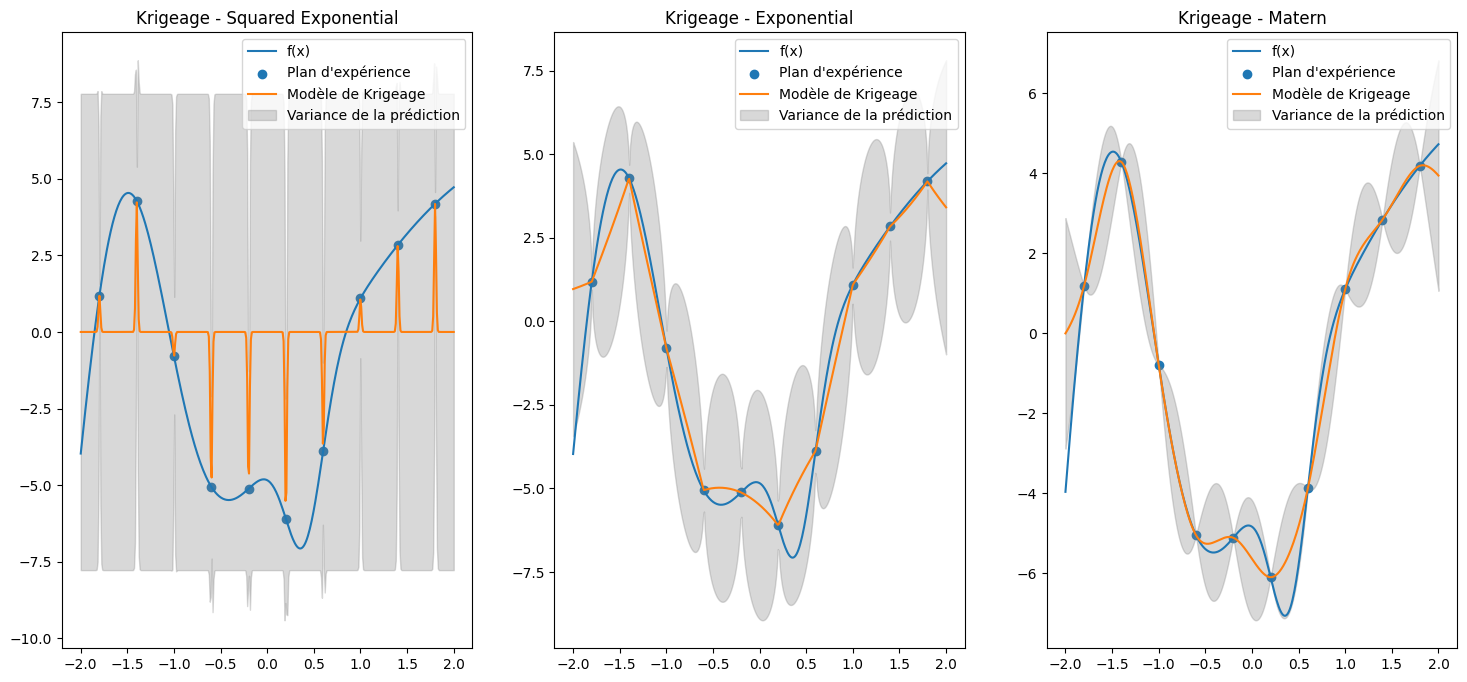

In [ ]:
_,axs = plt.subplots(1,3,figsize=(18,8))

y_fit = [y_fit_sexp, y_fit_exp, y_fit_matern]
covariances = [variance_model_sexp, variance_model_exp, variance_model_matern]
labels = ["Squared Exponential","Exponential","Matern"]

for i in range(3):
  plot_Kriging(axs[i], D, pXp, Z, D_test, y_fit[i], covariances[i], labels[i])

plt.legend()
plt.show()

Comme nous pouvons le vori sur les 3 graphiques ci-dessus, le choix du noyau de covariance semble être déterminant pour la qualité des résultats.

En effet, avec le noyau de covariance *Squared Exponential*, l'interpolation de la fonction n'est pas précise : lorsque l'on s'éloigne du plan d'expérience, le modèle ne peut pas faire mieux que de simplement donner la moyenne du processus sur [-2,2].

A l'inverse, avec les noyaux de type *Matern*, et *Exponential*, les prédictions semblent être meilleures. En particulier, le noyau de covariance de type *Matern* semble être le meilleur, compte tenu de la qualité de l'interpolation, et l'incertitude en chaque point.

### Génération de trajectoires

In [ ]:
def simulate_traj(krigingResult, D, nb_traj):
  D_test = ot.Mesh(D.reshape(-1, 1))
  # Construction du processus Gaussien associé au modèle de Krigeage
  process = ot.ConditionedGaussianProcess(krigingResult, D_test)
  # Simulation de nb_traj trajectoires
  trajectories = process.getSample(nb_traj)

  return trajectories

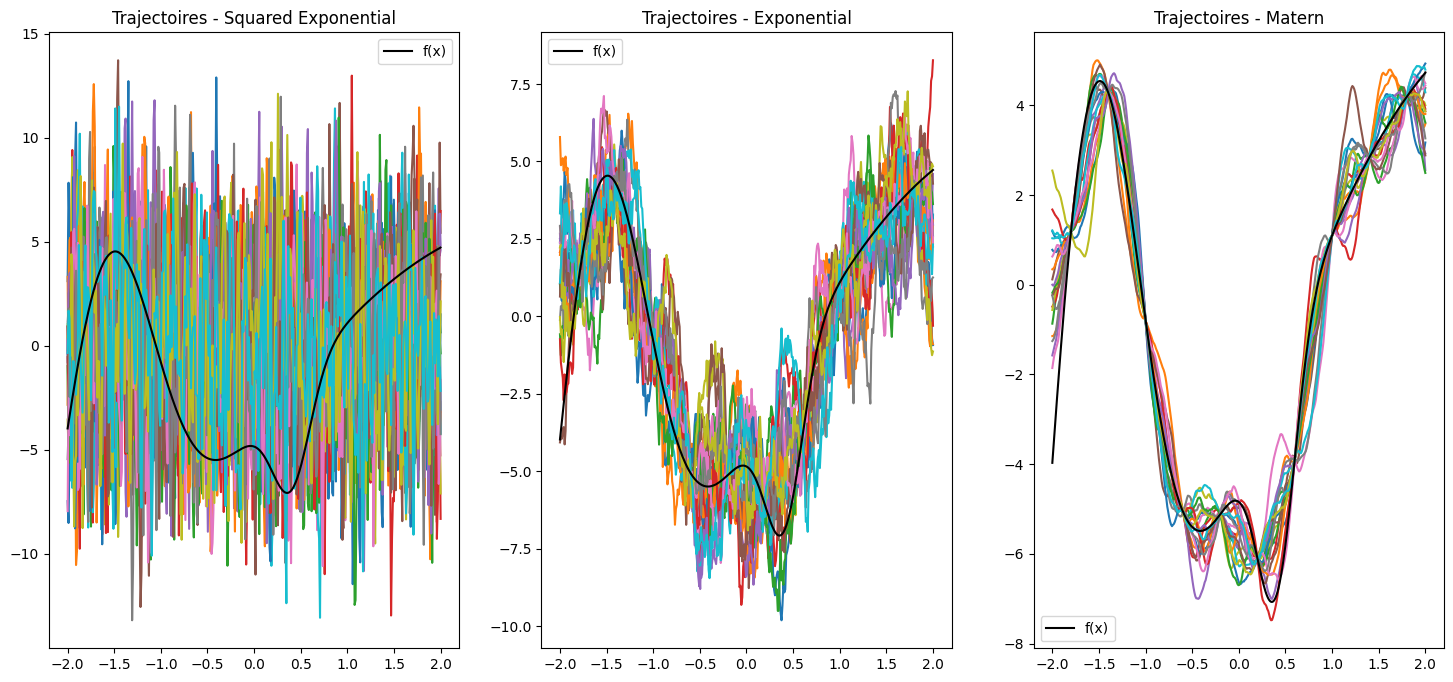

In [ ]:
# On souhaite générer 20 trajectoires
nb_traj = 20
# Récupération des trajectoires avec la fonction précédente
trajectoires_sexp = simulate_traj(krigingResult_sexp, D, nb_traj)
trajectoires_exp = simulate_traj(krigingResult_exp, D, nb_traj)
trajectoires_matern = simulate_traj(krigingResult_matern, D, nb_traj)

# Affichage des trajectoires
_,axs = plt.subplots(1,3,figsize=(18,8))

trajectoires = [trajectoires_sexp, trajectoires_exp, trajectoires_matern]
labels = ["Squared Exponential","Exponential","Matern"]

for i in range(3):
  for k in range(nb_traj):
    axs[i].plot(D_test, trajectoires[i][k])

  axs[i].set_title(f"Trajectoires - {labels[i]}")

axs[0].plot(D,f(D),label="f(x)",color="Black")
axs[1].plot(D,f(D),label="f(x)",color="Black")
axs[2].plot(D,f(D),label="f(x)",color="Black")

axs[0].legend()
axs[1].legend()
axs[2].legend()
plt.show()

Comme nous avions pu le prévoir avec les affichages précédents, c'est le dernier noyau de covariance qui semble être le meilleur : toutes les trajectoires sont assez proches de la valeur vraie de la fonction.

A l'inverse, le premier modèle de covariance est, en effet, très mauvais. Nous obtenons des trajectoires dont la variance est très grande, centrées sur la moyenne de la fonction sur l'intervalle d'étude.

### Recherche du meilleur noyau de covariance

#### Ajustement du modèle de Krigeage

In [ ]:
def fit_Kriging_optimal(pXp, Z, covariance, D):
    """
    Ajuste un modèle de Krigeage en optimisant les paramètres du noyau de covariance.
    """
    # Paramètres d'entrée à optimiser
    kriging_model = ot.KrigingAlgorithm(pXp, Z, covariance)
    kriging_model.setOptimizationAlgorithm(ot.Cobyla())  # Choix d'un algorithme d'optimisation
    kriging_model.run()

    # Récupération des résultats
    krigingResult = kriging_model.getResult()
    optimized_covariance = krigingResult.getCovarianceModel()
    krigingMetamodel = krigingResult.getMetaModel()
    variance_model = np.sqrt([[krigingResult.getConditionalCovariance(xx)[0, 0]] for xx in D.reshape((-1, 1))])

    return krigingResult, krigingMetamodel, variance_model

In [ ]:
# Ajustement des modèles de Krigeage
krigingResult_sexp_opt, krigingMetamodel_sexp_opt, variance_model_sexp_opt = fit_Kriging_optimal(pXp, Z, covariance_sexp, D)
krigingResult_exp_opt, krigingMetamodel_exp_opt, variance_model_exp_opt = fit_Kriging_optimal(pXp, Z, covariance_exp, D)
krigingResult_matern_opt, krigingMetamodel_matern_opt, variance_model_matern_opt = fit_Kriging_optimal(pXp, Z, covariance_matern, D)

In [ ]:
# Ajustement des modèles sur D
y_fit_sexp_opt = krigingMetamodel_sexp_opt(D_test).asPoint()
y_fit_exp_opt = krigingMetamodel_exp_opt(D_test).asPoint()
y_fit_matern_opt = krigingMetamodel_matern_opt(D_test).asPoint()

#### Affichage de l'ajustement

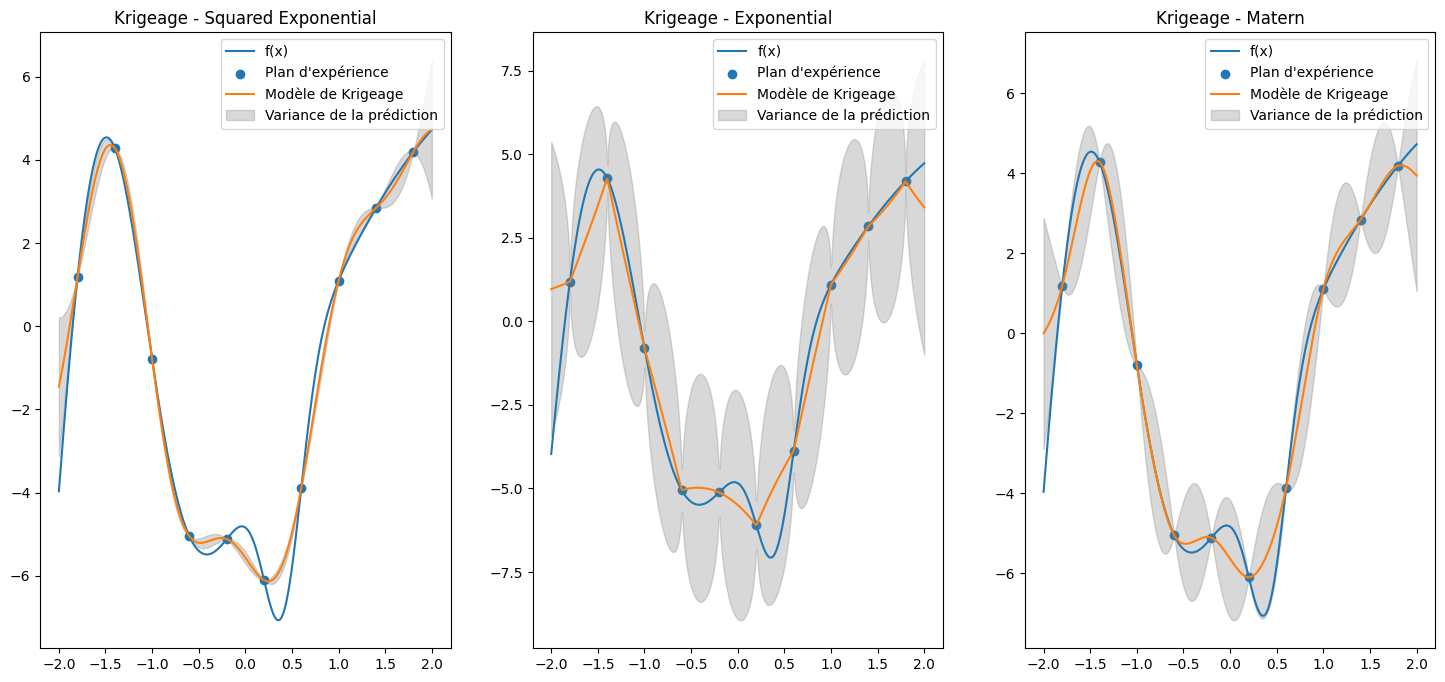

In [ ]:
_,axs = plt.subplots(1,3,figsize=(18,8))

y_fit_opt = [y_fit_sexp_opt, y_fit_exp_opt, y_fit_matern_opt]
covariances_opt = [variance_model_sexp_opt, variance_model_exp_opt, variance_model_matern_opt]
labels = ["Squared Exponential","Exponential","Matern"]

for i in range(3):
  plot_Kriging(axs[i], D, pXp, Z, D_test, y_fit_opt[i], covariances_opt[i], labels[i])

plt.show()

En optimisant les paramètres du noyau de covariance, les résultats sont assez différents. En particulier, pour le noyau de covariance *Squared Exponential*, la recherche de ses paramètres optimaux renvoie une interpolation bien meilleure de la fonction.

Là où, sans ajustement, la prédiction de la fonction était ramenée à sa moyenne lorsque l'on quittait le plan d'expérience, l'ajustement des paramètres du noyau permet de tirer profit des données sur le plan d'expérience pour interpoler la fonction sur tout l'intervalle d'étude.

Pour autant, malgré cette optimisation, la valeur vraie de la fonction ne se trouve pas dans l'intervalle de confiance donné par la variance estimée du modèle. Bien que l'estimation de la fonction soit bien meilleure, en certains points de l'intervalle, l'intervalle de confiance fournit est très petit, et la valeur vraie ne se situe pas dans celui-ci.

Ainsi, dans notre cas d'étude, le noyau de covariance de type *Matern* semble rester meilleur, dans le sens où la valeur vraie de la fonction se situe dans l'intervalle de confiance.

#### Génération de trajectoires

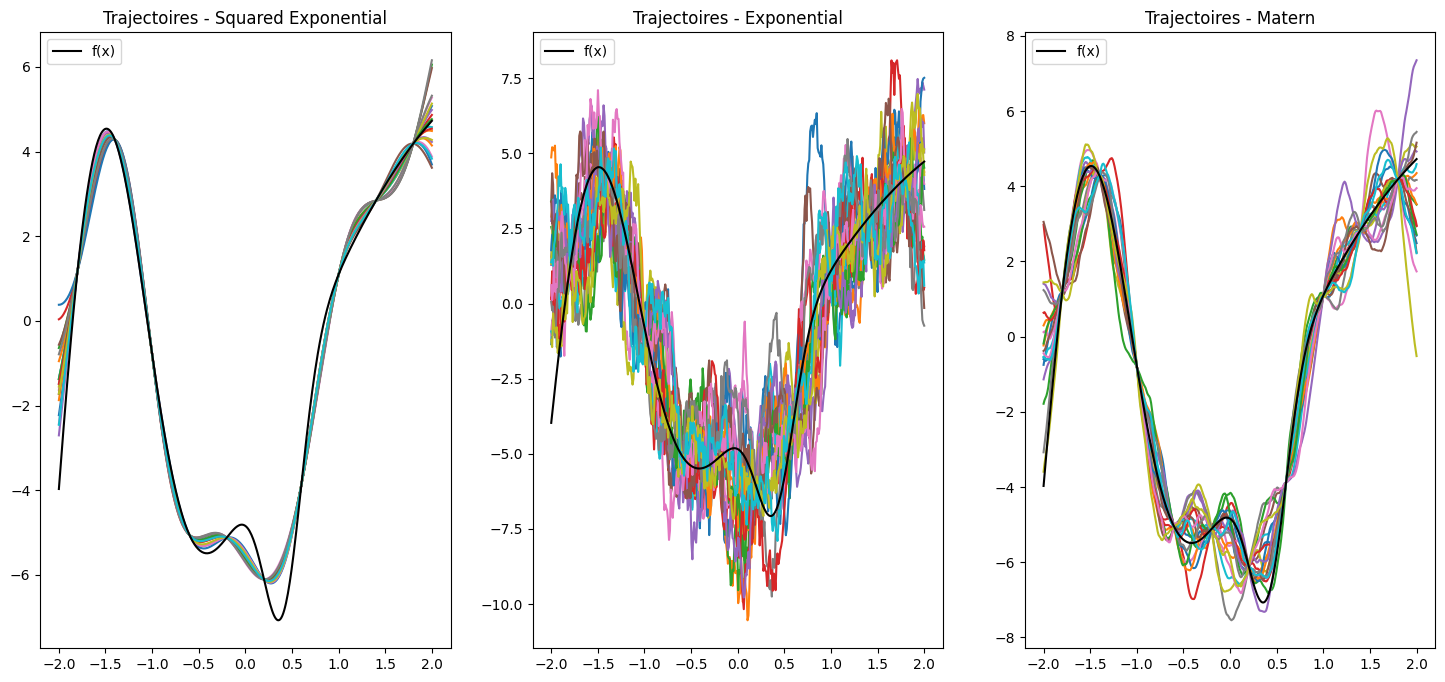

In [ ]:
# On souhaite générer 20 trajectoires
nb_traj = 20
# Récupération des trajectoires avec la fonction précédente
trajectoires_sexp_opt = simulate_traj(krigingResult_sexp_opt, D, nb_traj)
trajectoires_exp_opt = simulate_traj(krigingResult_exp_opt, D, nb_traj)
trajectoires_matern_opt = simulate_traj(krigingResult_matern_opt, D, nb_traj)

# Affichage des trajectoires
_,axs = plt.subplots(1,3,figsize=(18,8))

trajectoires_opt = [trajectoires_sexp_opt, trajectoires_exp_opt, trajectoires_matern_opt]
labels = ["Squared Exponential","Exponential","Matern"]

for i in range(3):
  for k in range(nb_traj):
    axs[i].plot(D_test, trajectoires_opt[i][k])

  axs[i].set_title(f"Trajectoires - {labels[i]}")

axs[0].plot(D,f(D),label="f(x)",color="Black")
axs[1].plot(D,f(D),label="f(x)",color="Black")
axs[2].plot(D,f(D),label="f(x)",color="Black")

axs[0].legend()
axs[1].legend()
axs[2].legend()
plt.show()

En simulant une vingtaine de trajectoires, nous observons les mêmes phénomènes que ceux abordés précédemment.

## Application du Krigeage à la surverse

On se propose dans ce TP d’utiliser un métamodèle pour étudier le risque d’inondation d’un site industriel en bord de rivière.


Une installation industrielle est installée en bordure d’une rivière. L’écoulement des crues (de débit aléatoire 𝑄) peut provoquer des hauteurs d’eau importantes, susceptibles d’inonder l’installation, si la cote atteinte pendant un épisode de crue (𝐻+𝑍𝑣) déborde par dessus la digue de protection (établie à la cote 𝐻𝑑+𝐶𝑏).

Le risque est caractérisé par une « surverse », c'est-à-dire le débordement du niveau de la rivière, qui est calculé de la manière suivante :
$$S=Z_v +H - H_d - C_b~,~~avec~~ H =(\frac{Q}{K_s.B.\sqrt{\frac{Z_m-Z_v}{L}}})^{3/5}$$
▪ $S$ désigne la surverse (en m), c’est-à-dire la différence entre la cote maximale de la crue et la cote de la digue, \\
▪ $H$ désigne la hauteur d’eau maximale (en m), \\
▪ $H_d$ est la hauteur de la digue, \\
▪ $Q$ désigne le débit de la rivière, \\
▪ $Z_m$ et $Z_v$ désignent la cote du fond du cours d’eau (en m NGF) respectivement en amont et en aval du tronçon, \\
▪ $C_b$ désigne la cote de la berge (en m NGF), \\
▪ $K_s$ désigne le coefficient de frottement du lit du cours d’eau (appelé coefficient de Strickler), \\
▪ $L$ désigne la longueur du tronçon de cours d’eau étudiée (en m), \\
▪ $B$ désigne la largeur du cours d’eau (en m).

Saving Schéma.png to Schéma (1).png


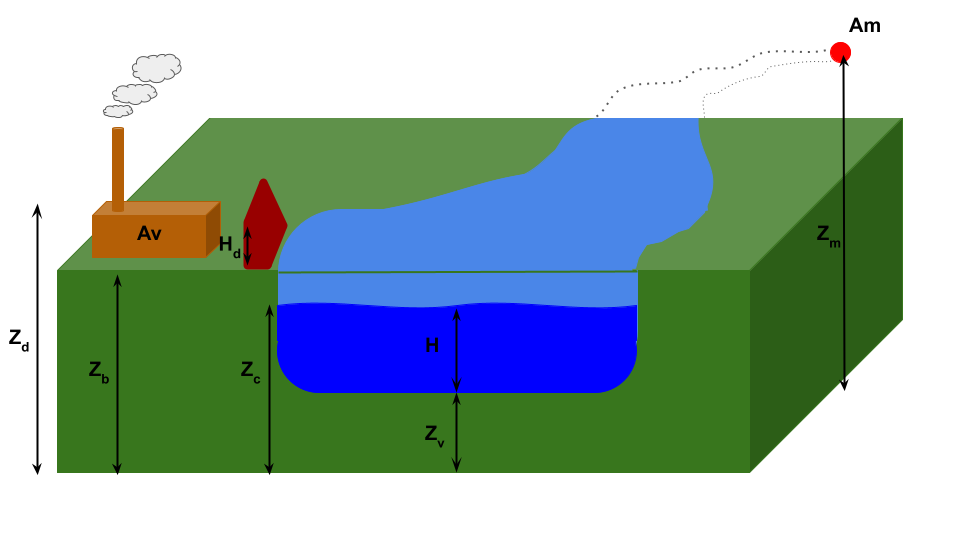

In [3]:
# Changer ça sur jupyter notebook pour que ça l'affiche biiieennn
from google.colab import files
uploaded = files.upload()

# Une fois l'image téléchargée, vous pouvez l'afficher avec cette commande
from IPython.display import Image
Image(filename='Schéma.png')

Concernant les variables définies ci-dessus, nous considèrerons les distributions suivantes :
$$
\begin{array}{|c|c|}
\hline
\textbf{Variable} & \textbf{Loi et paramètres} \\
\hline
Q & \mathcal{G}(\mu=1013,~ \beta=558),~ \in [500,~3000] \\
\hline
K_s & \mathcal{N}(\mu=30.0,~ \sigma=8),~ \in [15,~ +\infty] \\
\hline
Z_v & \mathcal{T}(a=49,~ b=51,~ c=50) \\
\hline
Z_m & \mathcal{T}(a=54,~ b=56,~ c=55) \\
\hline
H_d & \mathcal{U}(\text{min}=7,~ \text{max}=9) \\
\hline
C_b & \mathcal{T}(a=55,~ b=56,~ c=55.5) \\
\hline
L & \mathcal{T}(a=4990,~ b=5010,~ c=5000) \\
\hline
B & \mathcal{T}(a=295,~ b=305,~ c=300) \\
\hline
\end{array}
$$


### Analyse de la surverse

Dans cette première partie, nous allons considérer un échantillon d'apprentissage de $n$ évaluations de la surverse. Pour ces données d'entraînement, nous construirons un méta-modèle, basé sur :
- une régression linéaire ;
- ou une méta-modélisation par processus gaussien.

Pour le second cas, nous testerons plusieurs modèles de covariance et de dérive.

Comparer graphiquement les méta-modèles obtenus, en termes de reproduction des calculs utilisés pour l'identification des méta-modèles.

Question 3 : A partir d'un nouvel échantillon de 𝑁 = 1000 nouvelles évaluations de 𝑆, comparer la pertinence des méta-modèles obtenus en termes de prédictions de nouveaux échantillons.

Question 4 : Comparer ensuite les erreurs de prédictions moyennes. Commenter les différences.

Question 5 : Visualiser graphiquement l'incertitude de prédictions donnée par la méta-modélisation par processus gaussien.

#### Définition des fonctions définissant le problème

Tout d'abord, nous allons définir les fonctions de notre problé=ème : une fonction pour générer un échantillon des entrées, et une seconde permettant de calculer la hauteur d'eau à partir de ces variables.

In [4]:
# Définition des distributions des variables (selon les lois présentées ci-dessus)
Q = ot.Gumbel(1013,558)
Ks = ot.Normal(30.0,8)
Zv = ot.Triangular(49,50,51)
Zm = ot.Triangular(54,55,56)
Hd = ot.Uniform(7,9)
Cb = ot.Triangular(55,55.5,56)
L = ot.Triangular(4990,5000,5010)
B = ot.Triangular(295,300,305)

# Création de la loi conjointe à toutes les variables (hypothèse d'indépendance)
input_dist =  ot.JointDistribution([Q,Ks,Zv,Zm,Hd,Cb,L,B])

In [5]:
def init_sample(n,input_dist):
  """
  Fonction permettant de générer un échantillon de taille n des variables d'entrée de notre problème.

  Entrées :
    - n          : Integer             - Taille de l'échantillon à générer
    - input_dist : ot.JoinDistribution - Distribution conjointe des variables d'entrée

  Sortie :
    - Xsample : ot.Sample - Echantillon des variables d'entrée
  """
  # Création de l'échantillon
  Xsample = input_dist.getSample(n)
  # Tronquage des variables Q et Ks
  Xsample[:,0] = np.clip(Xsample[:,0],500,3000)
  Xsample[:,1] = np.clip(Xsample[:,1],15,np.max(Xsample[:,1]))

  return Xsample

In [6]:
def H(X):
  """
  Fonction qui calcule la hauteur de crue en fonction des variables d'entrée.

  Entrée :
    X : ot.Sample - Echantillon des variables d'entrée

  Sortie :
    h : ot.Sample - Echantillon de la hauteur de crue
  """
  # Convertion de l'échantillon en array NumPy
  X = np.array(X)
  # Récupération des échantillons de chaque variable d'entrée
  Q = X[:,0]
  Ks = X[:,1]
  Zv = X[:,2]
  Zm = X[:,3]
  Hd = X[:,4]
  Cb = X[:,5]
  L = X[:,6]
  B = X[:,7]
  # Calcul de la hauteur de crue
  h = (Q / (Ks * B * np.sqrt( (Zm - Zv) / L )))**(3/5)
  # Convertion de l'échantillon en Sample OpenTURNS
  h = ot.Sample(h.reshape(-1,1))

  return h

#### Définition des méta-modèles

Comme dit précédemment, nous allons appliquer une régression linéaire et une régression par processus gaussien à notre modèle. Nous devons donc construire les fonctions permettant de construire ces deux régressions, avec les données d'entraînement.

In [7]:
def fit_LR(X,H):
  """
  Fonction qui ajuste un modèle de régression aux données d'entrainement.

  Entrées :
    - X : ot.Sample - Echantillon des variables d'entrée
    - H : ot.Sample - Echantillon de la hauteur de crue

  Sorties :
    - result    : ot.LinearModelResult   - Résultat de l'ajustement
    - coeffs    : ot.Sample              - Coeffients de la régression linéaire
    - leverages : ot.Sample              - Facteurs de leverage de la régression linéaire
  """
  # Création du modèle Linéaire
  algo = ot.LinearModelAlgorithm(X, H)

  # Récupération des données d'ajustement
  result = algo.getResult()
  coeffs = result.getCoefficients()
  leverages = result.getLeverages()

  return result, coeffs, leverages

In [8]:
def fit_Gauss(X,H,covariance):
  """
  Fonction qui ajuste un modèle de Krigeage aux données d'entrainement.

  Entrées :
    - X          : ot.Sample          - Echantillon des variables d'entrée
    - H          : ot.Sample          - Echantillon de la hauteur de crue
    - covariance : ot.covarianceModel - Noyau de covariance considéré

  Sorties :
    - krigingResult    : ot.KrigingAlgorithmResult - Résultat de l'ajustement
    - krigingMetamodel : ot.MetaModel              - Méta-modèle de Krigeage
  """
  # Définition du modèle de Krigeage
  kriging_model = ot.KrigingAlgorithm(X, H, covariance)

  # Ajustement du modèle de Krigeage
  kriging_model.run()

  # Récupération des données d'ajustement
  krigingResult = kriging_model.getResult()
  krigingMetamodel = krigingResult.getMetaModel()

  return krigingResult, krigingMetamodel

#### Comparaison des deux méthodes

En utilisant les fonctions construites ci-dessous, nous pouvons ajuster les deux modèles à un jeu de donnée. Pour cette partie, nous considèrerons un nombre d'échantillons fixé, noté n, correspondant à notre budget de calcul (nombre d'évaluation de la fonction).

Ensuite, avec cet échantillon, nous serons en mesure de construire les deux modèles. Une première étape sera de comparer graphiquement les interpolations obtenues. Une seconde portera sur l'analyse quantitative des prédictions.

##### Comparaison graphique

Dans cette partie, on se propose de visualiser qualitativement l'ajustement des modèles aux données d'entraînement. Nous pourrons aussi visualiser ces mêmes prédictions sur un autre jeu de donnée. Bien entendu, cette seconde comparaison ne serait pas réalisable dans un contexte réel, puisque le budget alloué est fixé. Nous réaliserons tout de même cette comparaison, afin d'observer davantage les différences entre les deux modèles.

In [9]:
# Choix du nombre d'échantillons à générer
n = 100
# Création de l'échantillon
X_sample_train = init_sample(n,input_dist)

# Récupération de l'échantillon des hauteurs de crue
H_sample_train = H(X_sample_train)

# Ajustement du modèle linéaire et prédictions
result_LR, coeffs_LR, leverages_LR = fit_LR(X_sample_train,H_sample_train)
LR_fit_train = coeffs_LR[0] + (np.array(X_sample_train))@(np.array(coeffs_LR[1:]).T)

# Choix du noyau de covariance
covariance = ot.MaternModel(8)
# Ajustement du modèle par Krigeage et prédictions
result_K, Metamodel_K = fit_Gauss(X_sample_train,H_sample_train,covariance)
Kriging_fit_train = Metamodel_K(X_sample_train).asPoint()

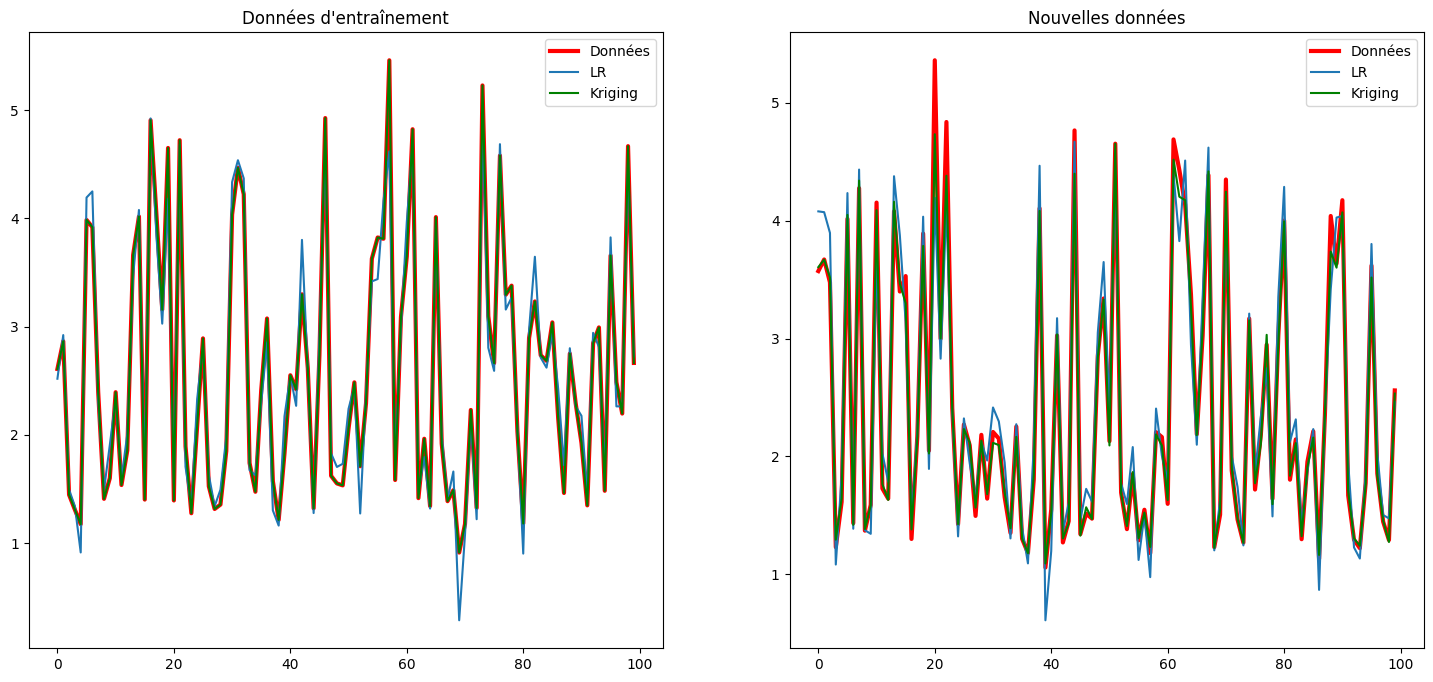

In [115]:
# Création d'un jeu de donnée parallèle, pour comparer les modèles
X_sample_test = init_sample(100,input_dist)
H_sample_test = H(X_sample_test)

# Prédictions des modèles sur ce nouveau jeu de données
LR_fit_test = coeffs_LR[0] + (np.array(X_sample_test))@(np.array(coeffs_LR[1:]).T)
Kriging_fit_test = Metamodel_K(X_sample_test).asPoint()

# Affichages
_,axs = plt.subplots(1,2,figsize=(18,8))
axs[0].plot(H_sample_train,label="Données",color='red',linewidth=3)
axs[0].plot(LR_fit_train,label="LR")
axs[0].plot(Kriging_fit_train,label="Kriging",color='green')
axs[0].set_title("Données d'entraînement")
axs[0].legend()

axs[1].plot(H_sample_test,label="Données",color='red',linewidth=3)
axs[1].plot(LR_fit_test,label="LR")
axs[1].plot(Kriging_fit_test,label="Kriging",color='green')
axs[1].set_title("Nouvelles données")
axs[1].legend()

In [11]:
rMSE_LR_train = np.sqrt( 1/100*np.sum((np.array(H_sample_train) - np.array(LR_fit_train).reshape(-1,1))**2) )
rMSE_Kriging_train = np.sqrt( 1/100*np.sum((np.array(H_sample_train) - np.array(Kriging_fit_train).reshape(-1,1))**2) )

rMSE_LR_test = np.sqrt( 1/100*np.sum((np.array(H_sample_test) - np.array(LR_fit_test).reshape(-1,1))**2) )
rMSE_Kriging_test = np.sqrt( 1/100*np.sum((np.array(H_sample_test) - np.array(Kriging_fit_test).reshape(-1,1))**2) )

print(" * RMSE *           :   Données d'entraînement   |   Nouvelles données")
print("Régression Linéaire :          ", np.round(rMSE_LR_train,3), "           |       ", np.round(rMSE_LR_test,3))
print("Krigeage            :          ", np.round(rMSE_Kriging_train,3), "             |       ", np.round(rMSE_Kriging_test,3))

 * RMSE *           :   Données d'entraînement   |   Nouvelles données
Régression Linéaire :           0.212            |        0.248
Krigeage            :           0.0              |        0.137


Sur le premier grahique, nous pouvons voir la force du modèle de Krigeage. En effet, ce modèle est un interpolateur exact, ce qui signifie que les prédictions réalisées sur les entrées simulées rendent les mêmes valeurs que la hauteur réelle. Nou observons d'ailleur un rMSE nul (ce qui est rassurant).

A l'inverse, ce n'est pas le cas pour le modèle de régression. En effet, comme nous pouvons le voir ci-dessus, les prédictions restent proches des valeurs exactes, mais ne suivent pas tout à fait les variations réelles (d'où un rMSE >0).


Sur le second graphique, un nouveau jeu de donnée est proposé. L'idée de cet affichage est d'observer si les deux modèles restent performants sur un jeu de donnée complètement différent. On obseve en effet que les courbes rendues sont proches de la courbe réelle. Il semblerait d'ailleurs que le modèle par Krigeage soit meilleur sur le test réalisé. La valeur du rMSE confirme d'ailleurs cette observations, bien que nous vérifierons cette assertion plus en détails dans la suite.

#### Comparaison de la pertinence des méta-modèles

Par comparaison graphique, il semblerait que les deux modèles soient assez bons. Pour s'en convaincre davantage, nous allons comparer qualitativement les erreurs de prédiction des deux modèles.

A cet effet, nous utiliserons notamment la méthode "One-at-a-Time" : nous ajustons le modèles sur n-1 entrées, et calculons l'erreur obtenue sur la prédiction de la n-ieme entrée. En considérant tous les ensemble de n-1 entrées possible, et en calculant l'erreur moyenne, nous serons en mesure de quantifier la qualité de chaque modèle.

En utilisant cette méthode, nous sommes donc capables de comparer quantitativement la qualité de plusieurs modèles avec un unique échantillon d'entrée. Nous pourrons bien entendu réaliser le même raisonnement avec un K-fold cross validation, où plusieurs entrées sont prises comme étant l'échantillon de validation, plutôt qu'une donnée unique.

##### Comparaison des erreurs de prédiction

Avant de réaliser de tels calculs, nous pouvons afficher les résidus des deux modèles sur l'échantillon de test présenté précédemment.

Encore une fois, ce graphique ne pourrait pas être obtenu dans un cadre opérationnel, mais peut nous permettre de nous convaincre de manière plus illustrative de la force de la régression par processus Gaussiens.

Valeur moyenne de l'erreur commise : 
 - Régression Linéaire             :  0.172
 - Krigeage                        :  0.051


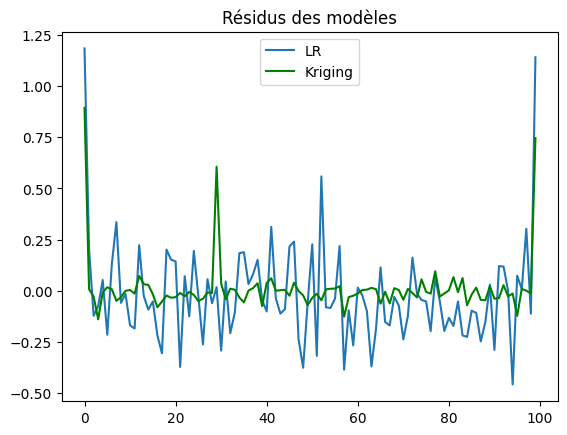

In [108]:
# Affichages
residus_LR = np.array(H_sample_test).reshape(-1) - np.array(LR_fit_test)
residus_Kriging = np.array(H_sample_test).reshape(-1) - np.array(Kriging_fit_test)

plt.plot(residus_LR,label="LR")
plt.plot(residus_Kriging,label="Kriging",color='green')
plt.title("Résidus des modèles")
plt.legend()

print("Valeur moyenne de l'erreur commise : ")
print(" - Régression Linéaire             : ",np.round(np.mean(np.abs(residus_LR)),3))
print(" - Krigeage                        : ",np.round(np.mean(np.abs(residus_Kriging)),3))

Comme nous pouvions nous y attendre, les résidus du modèle de Krigeage sont nettement plus petits.

Comme annoncé, afin de comparer les deux modèles dans un cadre plus réaliste, nous allons utiliser un K-fold cross validation avec des groupes de taille 1, 10 et 20.

In [28]:
def cross_validation(X,H,covariance,K):
  """
  Fonction réalisant la validation croisée par K-fold cross validation.

  Entrées :
    - X          : ot.Sample          - Echantillon des entrées
    - H          : ot.Sample          - Echantillon de la hauteur de crue
    - covariance : ot.covarianceModel - Noyau de covariance considéré
    - K          : Integer            - Nombre de folds de la validation croisée

  Sorties :
    - err_tot_LR : array - Tableau des erreurs commises par la régression linéaire
    - err_tot_K  : array - Tableau des erreurs commises par le Krigeage
  """
  # Taille de notre échantillon
  n = len(X)
  # Nombre d'itérations à réaliser
  nb_iter = int(np.floor(n/K))

  # Initisialisation des sorties
  err_tot_LR = []
  err_tot_K = []

  # Pour chaque groupe de K entrées
  for i in range(nb_iter):
      # On crée les données d'entrainement
      X_actual = ot.Sample(np.delete(X, range(K*i, K*i+K), axis=0))
      H_actual = ot.Sample(np.delete(H, range(K*i, K*i+K),axis=0))
      # On crée les données de validation
      X_test = ot.Sample(X[range(K*i, K*i+K)])
      H_test = ot.Sample(H[range(K*i, K*i+K)])

      # Ajustement des modèles
      _, coeffs, _ = fit_LR(X_actual,H_actual)
      _, Metamodel_K = fit_Gauss(X_actual,H_actual,covariance)

      # Prédictions réalisées sur les données de validation
      y_fit_K = Metamodel_K(X_test).asPoint()
      y_fit_LR = coeffs[0] + (np.array(X_test))@(np.array(coeffs[1:]).T)

      # Mise à jour des listes d'erreur
      err_tot_LR.append(np.abs(np.array(H_test) - np.array(y_fit_LR).reshape(-1,1))[0][0])
      err_tot_K.append(np.abs(np.array(H_test) - np.array(y_fit_K).reshape(-1,1))[0][0])

      # Affichage de la barre d'état
      s = "■"
      nb = int(np.floor(20*i/(nb_iter)))
      chaine = "["+ "".join([s] * nb) + "".join([" "] * (20-nb)) +"]"
      sys.stdout.flush()
      sys.stdout.write("\r" + chaine)  # "\r" permet de revenir au début de la ligne


  return err_tot_LR, err_tot_K


In [30]:
err_LR_1, err_K_1 = cross_validation(X_sample_train,H_sample_train,covariance,1)
err_LR_10, err_K_10 = cross_validation(X_sample_train,H_sample_train,covariance,10)
err_LR_20, err_K_20 = cross_validation(X_sample_train,H_sample_train,covariance,20)

[■■■■■■■■■■■■■■■■    ]

In [45]:
print("Erreur absolue commise :  One-at-a-Time  |   K = 10  |   K = 20  |")
print(" - Régression linéaire :      ", np.round(np.mean(err_LR_1),3), "     |   ", np.round(np.mean(err_LR_10),3), "  |   ", np.round(np.mean(err_LR_20),3)," |")
print(" - Krigeage            :      ", np.round(np.mean(err_K_1),3), "     |   ", np.round(np.mean(err_K_10),3), "  |   ", np.round(np.mean(err_K_20),3)," |")

Erreur absolue commise :  One-at-a-Time  |   K = 10  |   K = 20  |
 - Régression linéaire :       0.18      |    0.19   |    0.181  |
 - Krigeage            :       0.12      |    0.03   |    0.769  |


Les résultats obtenus confirment encore une fois les observations précédentes : l'erreur (absolue) commise par le modèle de Krigeage est significativement plus petite que celle du modèle linéaire.

##### Visualisation de l'incertitude

Avant de passer à la partie suivante, nous allons tirer profit d'un des avantages de la régression par processus Gaussiens : avec cette méthode, il est possible de quantifier l'erreur commise, en calculant la variance de la prédiction obtenue.

In [89]:
def compute_covariance(modelResult, X):
  """
  Calcule la variance associée à la prédiction par Krigeage.

  Entrées :
    - modelResult : ot.KrigingResult - Résultat de l'ajustement du modèle de Krigeage
    - X           ! ot.Sample        - Echantillon sur lequel calculer la covariance

  Sorties :
    - variance_model : array - Tableau des variances calculées
  """

  variance_model = np.sqrt([[modelResult.getConditionalCovariance(x)[0, 0]] for x in X])

  return variance_model.reshape(-1)

In [90]:
variance_K = compute_covariance(result_K,X_sample_test)

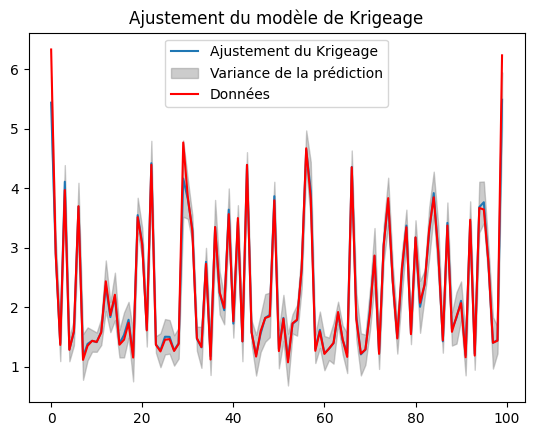

In [91]:
# Affichages
plt.plot(Kriging_fit_test, label="Ajustement du Krigeage")
plt.fill_between(range(len(variance_K)), [Kriging_fit_test[h] - 1.96 * variance_K[h] for h in range(len(variance_K))],
                  [Kriging_fit_test[h] + 1.96 * variance_K[h] for h in range(len(variance_K))],
                    color="grey", alpha=0.4,label="Variance de la prédiction")  # alpha pour la transparence

plt.plot(H_sample_test, label="Données",color="red")

plt.title(f"Ajustement du modèle de Krigeage")
plt.legend()

In [146]:
test = [(H_sample_test[h] <= Kriging_fit_test[h] + 1.96 * variance_K[h]) and (H_sample_test[h] >= Kriging_fit_test[h] - 1.96 * variance_K[h]) for h in range(len(variance_K))]

print("Sur l'échantillon de test, la valeur réelle se trouve dans l'intervalle dans", np.sum(test), "% des cas.")
if np.sum(test) < 100:
  print("Lorsque cette valeur ne se situe pas dans l'intervalle, l'écart moyen entre la valeur réelle et sa prédiction est de : ", np.round(np.mean(np.abs(np.array(H_sample_test[not test]) - np.array(Kriging_fit_test[not test]))),3),".")

Sur l'échantillon de test, la valeur réelle se trouve dans l'intervalle dans 95 % des cas.
Lorsque cette valeur ne se situe pas dans l'intervalle, l'écart moyen entre la valeur réelle et sa prédiction est de :  0.033 .


In [144]:
# Test pour une valeur de n plus grande
X_sample_test2 = init_sample(1000,input_dist)
H_sample_test2 = H(X_sample_test2)

# Prédictions des modèles sur ce nouveau jeu de données
Kriging_fit_test2 = Metamodel_K(X_sample_test2).asPoint()
variance_K2 = compute_covariance(result_K,X_sample_test2)

test2 = [(H_sample_test2[h] <= Kriging_fit_test2[h] + 1.96 * variance_K2[h]) and (H_sample_test2[h] >= Kriging_fit_test2[h] - 1.96 * variance_K2[h]) for h in range(len(variance_K2))]

print("Sur l'échantillon de test, la valeur réelle se trouve dans l'intervalle dans", (np.sum(test2))/10, "% des cas.")
if np.sum(test2) < 1000:
  print("Lorsque cette valeur ne se situe pas dans l'intervalle, l'écart moyen entre la valeur réelle et sa prédiction est de : ", np.round(np.mean(np.abs(np.array(H_sample_test2[not test2]) - np.array(Kriging_fit_test2[not test2]))),3),".")

Sur l'échantillon de test, la valeur réelle se trouve dans l'intervalle dans 98.3 % des cas.
Lorsque cette valeur ne se situe pas dans l'intervalle, l'écart moyen entre la valeur réelle et sa prédiction est de :  0.016 .


La valeur réelle de la hauteur de crue se trouve dans l'intervalle de confiance dans plus de 95% des cas, ce qui est rassurant.

Lorsque la valeur réelle n'est pas dans l'intervalle, elle reste assez proche de la prédiction, ce qui est aussi une bonne chose.

### Analyse du coût d'entretien

On s’intéresse dans un second temps au coût annuel d’entretien de la digue $C_{digue}$ (en M€) :
$$
C_{digue} = \mathbb{1}_{S>0}+\left[ 0.2+0.8.(1−e^{\frac{−1000}{𝑆^4}}) \right]. \mathbb{1}_{𝑆 \le 0}+\frac{1}{20}.(H_d.\mathbb{1}_{𝐻_𝑑>8}+8. \mathbb{1}_{𝐻_d \le 8})
$$

On se propose donc de réaliser la même analyse que précédemment, avec cette nouvelle fonction.

In [117]:
def C(X):
  """
  Fonction qui calcule la hauteur de crue en fonction des variables d'entrée.

  Entrée :
    X : ot.Sample - Echantillon des variables d'entrée

  Sortie :
    h : ot.Sample - Echantillon de la hauteur de crue
  """
  # Convertion de l'échantillon en array NumPy
  X = np.array(X)
  # Récupération des échantillons de chaque variable d'entrée
  Q = X[:,0]
  Ks = X[:,1]
  Zv = X[:,2]
  Zm = X[:,3]
  Hd = X[:,4]
  Cb = X[:,5]
  L = X[:,6]
  B = X[:,7]
  # Calcul de la hauteur de crue
  h = (Q / (Ks * B * np.sqrt( (Zm - Zv) / L )))**(3/5)

  # Calcul de la surverse
  S = Zv + h - Hd - Cb
  # Calcul du coût d'entretien
  C = 1 * (S > 0) + (0.2 + 0.8 * (1 - np.exp( -1000 / S**4 ))) * (S <= 0) + 1/20 * (Hd * (Hd > 8) + 8 * (Hd <= 8))
  C = ot.Sample(C.reshape(-1,1))

  return C

#### Application des deux modèles

Comme pour l'analyse faite précédemment, nous allons appliquer les modèle de régression linéaire et par processus gaussien à ce nouveau jeu de données.

Nous utiliserons les mêmes échantillons d'entrées que ceux utilisés dans la partie précédente.

In [112]:
# Récupération de l'échantillon des hauteurs de crue
C_sample_train = C(X_sample_train)

# Ajustement du modèle linéaire et prédictions
Cresult_LR, Ccoeffs_LR, Cleverages_LR = fit_LR(X_sample_train,C_sample_train)
CLR_fit_train = Ccoeffs_LR[0] + (np.array(X_sample_train))@(np.array(Ccoeffs_LR[1:]).T)

# Choix du noyau de covariance
covariance = ot.MaternModel(8)
# Ajustement du modèle par Krigeage et prédictions
Cresult_K, CMetamodel_K = fit_Gauss(X_sample_train,C_sample_train,covariance)
CKriging_fit_train = CMetamodel_K(X_sample_train).asPoint()

 * RMSE *           :   Données d'entraînement   |   Nouvelles données
Régression Linéaire :           0.019            |        0.022
Krigeage            :           0.0              |        0.012

Valeur moyenne de l'erreur commise : 
 - Régression Linéaire             :  0.016
 - Krigeage                        :  0.008


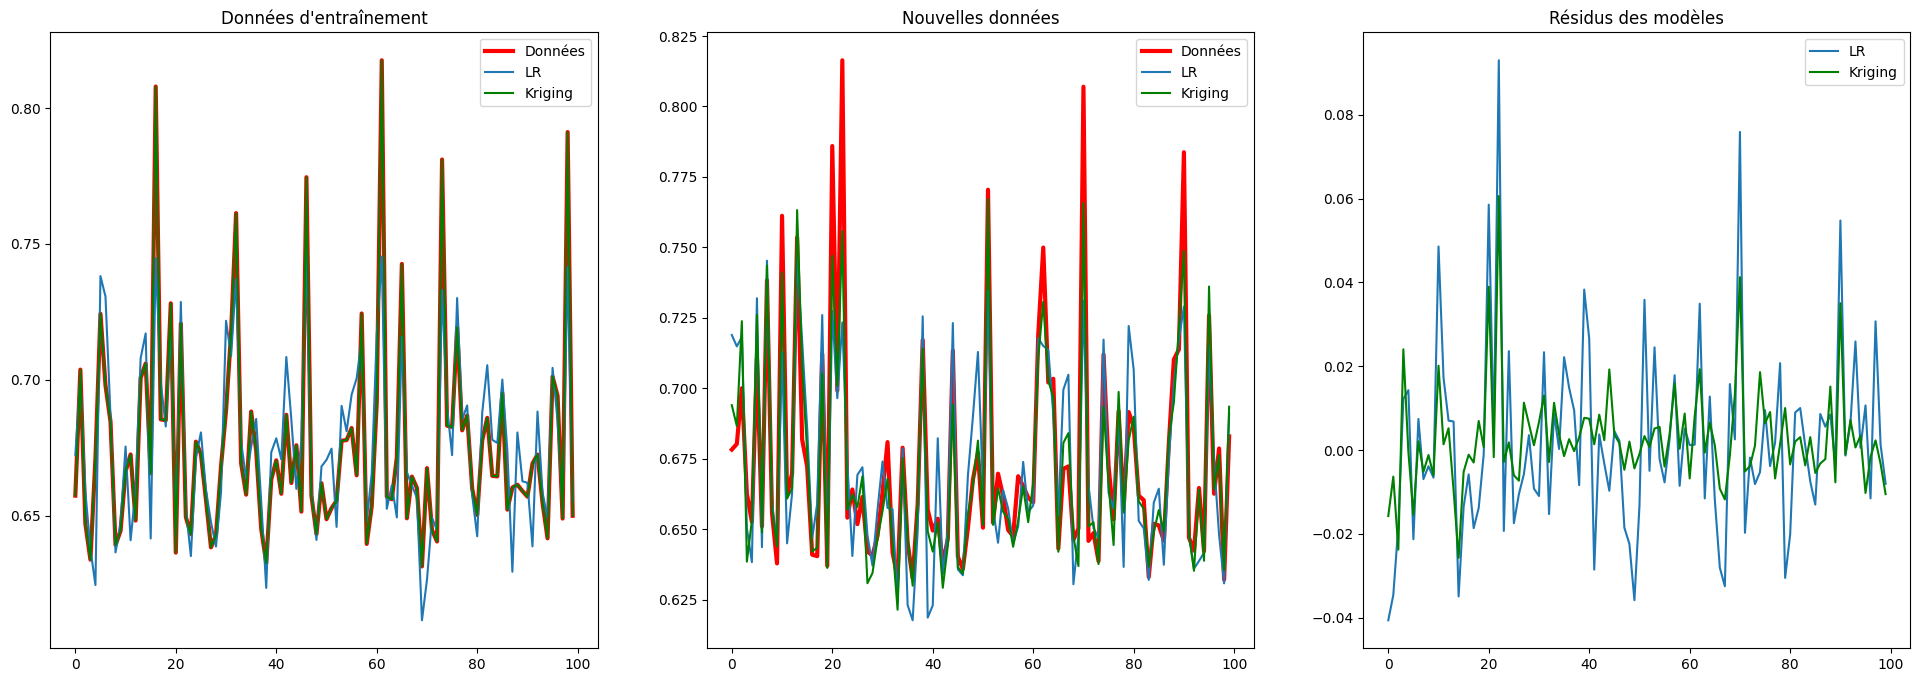

In [151]:
# Calcul de C pour les données de validation
C_sample_test = C(X_sample_test)

# Prédictions des modèles sur ce nouveau jeu de données
CLR_fit_test = Ccoeffs_LR[0] + (np.array(X_sample_test))@(np.array(Ccoeffs_LR[1:]).T)
CKriging_fit_test = CMetamodel_K(X_sample_test).asPoint()

# Affichages
_,axs = plt.subplots(1,3,figsize=(24,8))
axs[0].plot(C_sample_train,label="Données",color='red',linewidth=3)
axs[0].plot(CLR_fit_train,label="LR")
axs[0].plot(CKriging_fit_train,label="Kriging",color='green')
axs[0].set_title("Données d'entraînement")
axs[0].legend()

axs[1].plot(C_sample_test,label="Données",color='red',linewidth=3)
axs[1].plot(CLR_fit_test,label="LR")
axs[1].plot(CKriging_fit_test,label="Kriging",color='green')
axs[1].set_title("Nouvelles données")
axs[1].legend()

# Calculs des rMSE
CrMSE_LR_train = np.sqrt( 1/100*np.sum((np.array(C_sample_train) - np.array(CLR_fit_train).reshape(-1,1))**2) )
CrMSE_Kriging_train = np.sqrt( 1/100*np.sum((np.array(C_sample_train) - np.array(CKriging_fit_train).reshape(-1,1))**2) )

CrMSE_LR_test = np.sqrt( 1/100*np.sum((np.array(C_sample_test) - np.array(CLR_fit_test).reshape(-1,1))**2) )
CrMSE_Kriging_test = np.sqrt( 1/100*np.sum((np.array(C_sample_test) - np.array(CKriging_fit_test).reshape(-1,1))**2) )

# Affichages
print(" * RMSE *           :   Données d'entraînement   |   Nouvelles données")
print("Régression Linéaire :          ", np.round(CrMSE_LR_train,3), "           |       ", np.round(CrMSE_LR_test,3))
print("Krigeage            :          ", np.round(CrMSE_Kriging_train,3), "             |       ", np.round(CrMSE_Kriging_test,3))

# Calcul des résidus des deux modèles
Cresidus_LR = np.array(C_sample_test).reshape(-1) - np.array(CLR_fit_test)
Cresidus_Kriging = np.array(C_sample_test).reshape(-1) - np.array(CKriging_fit_test)
# Affichage du graphe
axs[2].plot(Cresidus_LR,label="LR")
axs[2].plot(Cresidus_Kriging,label="Kriging",color='green')
axs[2].set_title("Résidus des modèles")
axs[2].legend()

print("")
print("Valeur moyenne de l'erreur commise : ")
print(" - Régression Linéaire             : ",np.round(np.mean(np.abs(Cresidus_LR)),3))
print(" - Krigeage                        : ",np.round(np.mean(np.abs(Cresidus_Kriging)),3))

Nous pouvons globalement faire les mêmes remarques que pour l'analyse précédente. En effet, le modèle de régression par processus Gaussien semble toujours être meilleur que la régression linéaire. Toutefois, les résidus de ce modèles semblent être plus importants ici, avec notamment des pics de plus grande amplitude.

#### Comparaison des erreurs de prédiction

Comme pour l'analyse précédente, nous allons, pour un échantillon de taille fixée, réaliser un K-fold cross validation, afin de quantifier et de comparer la qualité des deux modèles sur ce nouveau jeu de données.

In [155]:
Cerr_LR_1, Cerr_K_1 = cross_validation(X_sample_train,C_sample_train,covariance,1)
Cerr_LR_10, Cerr_K_10 = cross_validation(X_sample_train,C_sample_train,covariance,10)
Cerr_LR_20, Cerr_K_20 = cross_validation(X_sample_train,C_sample_train,covariance,20)
print("")
print("Erreur absolue commise :  One-at-a-Time  |   K = 10  |   K = 20  |")
print(" - Régression linéaire :      ", np.round(np.mean(Cerr_LR_1),3), "    |  ", np.round(np.mean(Cerr_LR_10),3), "  |   ", np.round(np.mean(Cerr_LR_20),3)," |")
print(" - Krigeage            :      ", np.round(np.mean(Cerr_K_1),3), "     |  ", np.round(np.mean(Cerr_K_10),3), "  |   ", np.round(np.mean(Cerr_K_20),3),"  |")

[■■■■■■■■■■■■■■■■    ]
Erreur absolue commise :  One-at-a-Time  |   K = 10  |   K = 20  |
 - Régression linéaire :       0.016     |   0.018   |    0.015  |
 - Krigeage            :       0.01      |   0.006   |    0.01   |


Exactement comme pour le cas précédent, le modèle de régression par processus Gaussien semble, de nouveau, être plus performant en termes de prédictions, comparativement au modèle linéaire.

#### Prise en compte de la variance du Krigeage

Et enfin, nous pouvons ajouter la variance des prédictions pour le modèle de Krigeage.

Sur l'échantillon de test, la valeur réelle se trouve dans l'intervalle dans 100 % des cas.


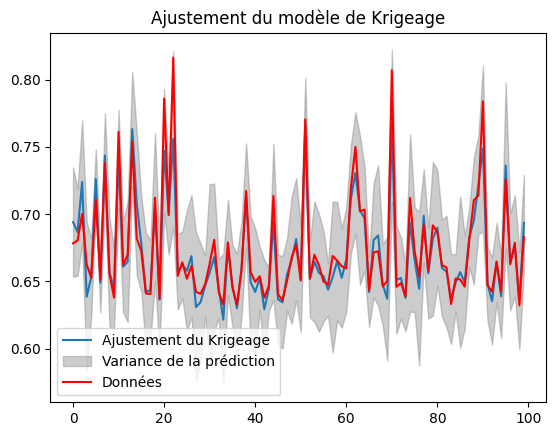

In [153]:
Cvariance_K = compute_covariance(Cresult_K,X_sample_test)

# Affichages
plt.plot(CKriging_fit_test, label="Ajustement du Krigeage")
plt.fill_between(range(len(Cvariance_K)), [CKriging_fit_test[h] - 1.96 * Cvariance_K[h] for h in range(len(Cvariance_K))],
                  [CKriging_fit_test[h] + 1.96 * Cvariance_K[h] for h in range(len(Cvariance_K))],
                    color="grey", alpha=0.4,label="Variance de la prédiction")  # alpha pour la transparence

plt.plot(C_sample_test, label="Données",color="red")

plt.title(f"Ajustement du modèle de Krigeage")
plt.legend()

Ctest = [(C_sample_test[h] <= CKriging_fit_test[h] + 1.96 * Cvariance_K[h]) and (C_sample_test[h] >= CKriging_fit_test[h] - 1.96 * Cvariance_K[h]) for h in range(len(Cvariance_K))]

print("Sur l'échantillon de test, la valeur réelle se trouve dans l'intervalle dans", np.sum(Ctest), "% des cas.")
if np.sum(Ctest) < 100:
  print("Lorsque cette valeur ne se situe pas dans l'intervalle, l'écart moyen entre la valeur réelle et sa prédiction est de : ", np.round(np.mean(np.abs(np.array(C_sample_test[not Ctest]) - np.array(CKriging_fit_test[not Ctest]))),3),".")

In [154]:
# Test pour une valeur de n plus grande
X_sample_test2 = init_sample(1000,input_dist)
C_sample_test2 = C(X_sample_test2)

# Prédictions des modèles sur ce nouveau jeu de données
CKriging_fit_test2 = CMetamodel_K(X_sample_test2).asPoint()
Cvariance_K2 = compute_covariance(Cresult_K,X_sample_test2)

Ctest2 = [(C_sample_test2[h] <= CKriging_fit_test2[h] + 1.96 * Cvariance_K2[h]) and (C_sample_test2[h] >= CKriging_fit_test2[h] - 1.96 * Cvariance_K2[h]) for h in range(len(Cvariance_K2))]

print("Sur l'échantillon de test, la valeur réelle se trouve dans l'intervalle dans", (np.sum(Ctest2))/10, "% des cas.")
if np.sum(Ctest2) < 1000:
  print("Lorsque cette valeur ne se situe pas dans l'intervalle, l'écart moyen entre la valeur réelle et sa prédiction est de : ", np.round(np.mean(np.abs(np.array(C_sample_test2[not Ctest2]) - np.array(CKriging_fit_test2[not Ctest2]))),3),".")

Sur l'échantillon de test, la valeur réelle se trouve dans l'intervalle dans 98.9 % des cas.
Lorsque cette valeur ne se situe pas dans l'intervalle, l'écart moyen entre la valeur réelle et sa prédiction est de :  0.003 .


Ici, comme pour le cas précédent, la valeur réelle du coût d'entretien se situe dans l'intervalle de prédiction dans plus de 95% des cas.

La variance des prédictions semble ici être plus grande, mais ceci s'avère être un effet d'échelle. En effet, S prend des valeurs bien plus petites, et dans un intervalle réduit par rapport à celui de H.

In [174]:
Hvar_rel = variance_K / np.mean(H_sample_test)
Cvar_rel = Cvariance_K / np.mean(C_sample_test)

print("Variance moyenne relative à l'ordre de grandeur de la variable de sortie : ")
print(" - Hauteur d'eau    : ", np.round(np.mean(Hvar_rel),3))
print(" - Coût d'entretien : ", np.round(np.mean(Cvar_rel),3))

Variance moyenne relative à l'ordre de grandeur de la variable de sortie : 
 - Hauteur d'eau    :  0.064
 - Coût d'entretien :  0.03


En effet, comme nous pouvons le voir, la variance moyenne ramenée à l'ordre de grandeur de la variable de sortie est plus grande dans la première analyse que dans la seconde. L'observation précédente est donc due au zoom graphique.

## Conclusion

*Pour conclure, lors de ce TP nous avons pu mettre en pratique de nombreuses notions théoriques étudiées en cours. En mettant en place plusieurs plans d'expérience, nous avons pu comprendre et illustrer l'intérêt des différentes stratégies de remplissage d'un espace.*

*Ensuite, à travers un exemple simple, suivi d'une mise en pratique sur un problème plus complexe, nous avons pu appréhender l'ajustement d'un modèle de Krigeage sur une fonction uni- et multi-variée. Cette mise en pratique a permis d'illustrer les avantages de la régression par Processus Gaussien, face à d'autres modèles, comme la régression linéaire par exemple, et nous a aussi permis d'implémenter quelques méthodes quantitatives et qualitatives d'analyse de la qualité de son ajustement.*

*Les différentes analyses réalisées nous ont permis d'observer par la pratique que le Krigeage est un outil puissant d'interpolation. En utilisant cette méthode de régression, il est possible de simplifier un modèle, parfois très complexe, afin de l'utiliser à des fins de simulation. Cet outil semble donc très intéressant pour notre cas d'étude.*

*Ainsi, en cumulant la construction d'un plan d'expérience efficace, et une interpolation par processus Gaussiens, nous serions en mesure d'obtenir un très bon métamodèle, qui pourrait ensuite être utilisé comme un outil de simulation, ayant pour but du dimensionner la digue, afin de repousser 99.99% des plus grandes crues par exemple.*